# Notebook 1 - Preparacion del modelo con COBRApy

Objetivo:
- Cargar `yeast-GEM.xml` en un objeto `model`.
- Aplicar la preparacion metabolica usada en el pipeline.
- Exportar `out/S.csv`, `out/lb.csv`, `out/ub.csv`.
- Exportar tambien `out/rxn_ids.txt`, `out/met_ids.txt` y `out/model_ready.xml`.


In [1]:
from pathlib import Path
import numpy as np
import cobra
from cobra.util.array import create_stoichiometric_matrix

OUT_DIR = Path("out")
OUT_DIR.mkdir(exist_ok=True)

SBML_PATH = Path("yeast-GEM.xml")
assert SBML_PATH.is_file(), f"No se encontro SBML: {SBML_PATH.resolve()}"

MODEL_READY_SBML = OUT_DIR / "model_ready.xml"
S_FILE = OUT_DIR / "S.csv"
LB_FILE = OUT_DIR / "lb.csv"
UB_FILE = OUT_DIR / "ub.csv"
RXN_FILE = OUT_DIR / "rxn_ids.txt"
MET_FILE = OUT_DIR / "met_ids.txt"

print(f"SBML: {SBML_PATH.resolve()}")
print(f"OUT_DIR: {OUT_DIR.resolve()}")


SBML: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\yeast-GEM.xml
OUT_DIR: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out


In [2]:
model = cobra.io.read_sbml_model(str(SBML_PATH))

print("Modelo cargado")
print(f"- Metabolitos: {len(model.metabolites)}")
print(f"- Reacciones: {len(model.reactions)}")
print(f"- Genes: {len(model.genes)}")

rxn_ids = {r.id for r in model.reactions}
obj_candidates = ["r_2111"]
obj_id = next((rid for rid in obj_candidates if rid in rxn_ids), None)
print(f"- Objetivo candidato: {obj_id}")


Modelo cargado
- Metabolitos: 2806
- Reacciones: 4131
- Genes: 1161
- Objetivo candidato: r_2111


In [3]:
key_rxn_ids = ["r_1761", "r_1714", "r_1709", "r_1992", "r_4046", "r_4598"]
METS_ANAEROBIC_BYPASS = ["s_3714[c]", "s_1198[c]", "s_1203[c]", "s_1207[c]", "s_1212[c]", "s_0529[c]"]

rxn_idx = {r.id: i + 1 for i, r in enumerate(model.reactions)}
met_idx = {m.id: i + 1 for i, m in enumerate(model.metabolites)}

rxn_nms = {r.id: r.name for r in model.reactions}
met_nms = {m.id: m.name for m in model.metabolites}

print()
print("Chequeo de reacciones clave")
for rid in key_rxn_ids:
    found = rid in rxn_idx
    idx = rxn_idx[rid] if found else -1
    name = rxn_nms.get(rid, "Unknown")
    print(f"- {rid:8s} found={found} idx={idx} name={name}")

print()
print("Chequeo de metabolitos clave")
for mid in METS_ANAEROBIC_BYPASS:
    found = mid in met_idx
    alt = mid.replace("[c]", "")
    found_alt = (not found) and (alt in met_idx)
    idx = met_idx[mid] if found else (met_idx[alt] if found_alt else -1)
    print(f"- {mid:10s} found={found or found_alt} idx={idx} name={met_nms.get(mid, met_nms.get(alt, 'Unknown'))}")



Chequeo de reacciones clave
- r_1761   found=True idx=1221 name=ethanol exchange
- r_1714   found=True idx=1180 name=D-glucose exchange
- r_1709   found=True idx=1175 name=D-fructose exchange
- r_1992   found=True idx=1408 name=oxygen exchange
- r_4046   found=True idx=3411 name=non-growth associated maintenance reaction
- r_4598   found=True idx=3948 name=cofactor pseudoreaction

Chequeo de metabolitos clave
- s_3714[c]  found=True idx=2208 name=heme a
- s_1198[c]  found=True idx=942 name=NAD
- s_1203[c]  found=True idx=947 name=NADH
- s_1207[c]  found=True idx=951 name=NADP(+)
- s_1212[c]  found=True idx=955 name=NADPH
- s_0529[c]  found=True idx=400 name=coenzyme A


In [4]:
def find_metabolite(mdl, mid):
    met_ids = {m.id for m in mdl.metabolites}
    if mid in met_ids:
        return mdl.metabolites.get_by_id(mid)
    clean = mid.replace("[c]", "")
    if clean in met_ids:
        return mdl.metabolites.get_by_id(clean)
    return None

print(f"Reacción r_4598 antes: {model.reactions.get_by_id('r_4598').build_reaction_string()}")

removed = 0.0
if "r_4598" in {r.id for r in model.reactions}:
    rcof = model.reactions.get_by_id("r_4598")
    updates = {}
    for mid in METS_ANAEROBIC_BYPASS:
        met = find_metabolite(model, mid)
        if met is None:
            continue
        coef = rcof.metabolites.get(met, 0.0)
        if coef != 0:
            updates[met] = -coef
            removed += abs(coef)
    if updates:
        rcof.add_metabolites(updates)

print(f"- Metabolitos eliminados de r_4598: {len(METS_ANAEROBIC_BYPASS)}")
print(f"Reacción r_4598 actualizada: {model.reactions.get_by_id('r_4598').build_reaction_string()}")

Reacción r_4598 antes: 0.000190000006114133 s_0529 + 9.99999974737875e-06 s_0687 + 1e-06 s_0750 + 0.00264999992214143 s_1198 + 0.000150000007124618 s_1203 + 0.000569999974686652 s_1207 + 0.00270000007003546 s_1212 + 0.000989999971352518 s_1405 + 1.20000004244503e-06 s_1475 + 6.34000025456771e-05 s_1487 + 9.99999997475243e-07 s_3714 --> s_4205
- Metabolitos eliminados de r_4598: 6
Reacción r_4598 actualizada: 9.99999974737875e-06 s_0687 + 1e-06 s_0750 + 0.000989999971352518 s_1405 + 1.20000004244503e-06 s_1475 + 6.34000025456771e-05 s_1487 --> s_4205


In [5]:
# --- Configuracion de bounds con trazabilidad ---

# Index rapido por ID para evitar busquedas repetidas
rxn_by_id = {r.id: r for r in model.reactions}
change_log = []

# Trazas configurables (ajustables)
VITAMIN_TRACE_LB = -1e-2   # traza mas elevada para vitaminas
ION_TRACE_LB = -1e-3       # trazas para iones esenciales


def _fmt_bound(x):
    return f"{x:.3f}" if isinstance(x, (int, float)) else str(x)


def _short(txt, n=70):
    txt = (txt or "").strip()
    return txt if len(txt) <= n else txt[: n - 3] + "..."


def set_bounds_logged(mdl, rid, lb=None, ub=None, group="", note=""):
    rec = {
        "group": group,
        "rid": rid,
        "note": note,
        "status": "MISSING",
        "name": "",
        "old_lb": None,
        "old_ub": None,
        "new_lb": None,
        "new_ub": None,
    }

    if rid not in rxn_by_id:
        print(f"  [MISSING] {rid:8s} | no existe en el modelo")
        change_log.append(rec)
        return rec

    r = rxn_by_id[rid]
    old_lb, old_ub = float(r.lower_bound), float(r.upper_bound)
    new_lb = old_lb if lb is None else float(lb)
    new_ub = old_ub if ub is None else float(ub)

    r.lower_bound = new_lb
    r.upper_bound = new_ub

    rec.update(
        {
            "status": "UPDATED",
            "name": r.name,
            "old_lb": old_lb,
            "old_ub": old_ub,
            "new_lb": new_lb,
            "new_ub": new_ub,
        }
    )
    change_log.append(rec)

    print(
        f"  [OK] {rid:8s} | {_short(r.name, 46):46s} | "
        f"({_fmt_bound(old_lb):>8s}, {_fmt_bound(old_ub):>8s}) -> "
        f"({_fmt_bound(new_lb):>8s}, {_fmt_bound(new_ub):>8s})"
    )
    return rec


def apply_group(group_name, reaction_ids, lb=None, ub=None, note=""):
    print("\n" + "=" * 100)
    print(f"Grupo: {group_name}")
    print(f"Objetivo de bounds: lb={lb if lb is not None else 'sin cambio'}, ub={ub if ub is not None else 'sin cambio'}")
    if note:
        print(f"Nota: {note}")
    print("-" * 100)
    for rid in reaction_ids:
        set_bounds_logged(model, rid, lb=lb, ub=ub, group=group_name, note=note)


# Reglas de manipulacion, agrupadas por sentido biologico/proceso
ALL_N_SOURCE_IDS = [
    "r_1654", "r_1904", "r_1891", "r_1889", "r_1880", "r_1881",
    "r_1873", "r_1879", "r_1810", "r_1906", "r_1911", "r_1914",
    "r_1899", "r_1897", "r_1903", "r_1913", "r_1912", "r_1893",
    "r_1900", "r_1902", "r_1883", "r_1987", "r_1800",
]

KINETIC_N_SOURCE_IDS = [
    "r_1654",  # NH4+
    "r_1879",  # Arg
    "r_1891",  # Gln
    "r_1889",  # Glu
    "r_1906",  # Ser
    "r_1911",  # Thr
    "r_1873",  # Ala
    "r_1912",  # Trp
]

GROUP_RULES = [
    {
        "group": "Anaerobiosis (O2 apagado)",
        "ids": ["r_1992"],
        "lb": 0.0,
        "ub": 0.0,
        "note": "Forzar intercambio de oxigeno en cero.",
    },
    {
        "group": "Suplementos anaerobicos abiertos",
        "ids": ["r_1757", "r_1915", "r_1994", "r_2106", "r_2134", "r_2137", "r_2189"],
        "lb": -1000.0,
        "ub": 0.0,
        "note": "Permitir captacion de suplementos en anaerobiosis.",
    },
    {
        "group": "Shuttles cerrados",
        "ids": ["r_0713", "r_0714", "r_0487"],
        "lb": 0.0,
        "ub": 0.0,
        "note": "Se aplican bounds asimetricos por reaccion.",
    },
    {
        "group": "Fuentes de carbono",
        "ids": ["r_1714", "r_1709"],
        "lb": -1000.0,
        "ub": 0.0,
        "note": "Glucosa y fructosa solo como uptake.",
    },
    {
        "group": "Fuentes de nitrogeno (todos)",
        "ids": ALL_N_SOURCE_IDS,
        "lb": 0.0,
        "ub": 0.0,
        "note": "23 fuentes de N inhabilitadas para captacion.",
    },
    {
        "group": "Fuentes de nitrogeno (medio vinico) - cinetica",
        "ids": KINETIC_N_SOURCE_IDS,
        "lb": -1000.0,
        "ub": 0.0,
        "note": "7 fuentes de N cineticas habilitadas para captacion.",
    },
    {
        "group": "Vitaminas",
        "ids": ["r_2067", "r_1671", "r_1967", "r_2028", "r_1548", "r_2038", "r_1947"],
        "lb": VITAMIN_TRACE_LB,
        "ub": 0.0,
        "note": "Vitaminas en traza elevada (evitar uso masivo como carbono).",
    },
    {
        "group": "Fosfato abierto",
        "ids": ["r_2005"],
        "lb": -1000.0,
        "ub": 0.0,
        "note": "Liberar captacion de fosfato para diagnostico.",
    },
    {
        "group": "Sulfato abierto",
        "ids": ["r_2060"],
        "lb": -1000.0,
        "ub": 0.0,
        "note": "Liberar captacion de sulfato para diagnostico.",
    },
    {
        "group": "Iones esenciales",
        "ids": ["r_2020", "r_1861", "r_4596", "r_4597", "r_4594", "r_4600", "r_4595", "r_4593"],
        "lb": ION_TRACE_LB,
        "ub": 0.0,
        "note": "Iones en traza.",
    },
    {
        "group": "Productos abiertos",
        "ids": ["r_1761", "r_1808", "r_1634", "r_2056", "r_1549", "r_1546", "r_1552", "r_1765", "r_1867", "r_1866", "r_1862", "r_1865"],
        "lb": 0.0,
        "ub": 1000.0,
        "note": "Excrecion permitida.",
    },
    {
        "group": "Agua y protones",
        "ids": ["r_2100", "r_1832"],
        "lb": -1000.0,
        "ub": 1000.0,
    },
]

# Aplicar grupos estandar
for rule in GROUP_RULES:
    # Caso especial: shuttles con limites asimetricos
    if rule["group"] == "Shuttles cerrados":
        print("\n" + "=" * 100)
        print(f"Grupo: {rule['group']}")
        print("Nota: Cierres especificos por reaccion")
        print("-" * 100)
        set_bounds_logged(model, "r_0713", lb=0.0, ub=None, group=rule["group"], note="Cerrar uptake inverso")
        set_bounds_logged(model, "r_0714", lb=0.0, ub=None, group=rule["group"], note="Cerrar uptake inverso")
        set_bounds_logged(model, "r_0487", lb=None, ub=0.0, group=rule["group"], note="Cerrar direccion directa")
        continue

    apply_group(
        rule["group"],
        rule["ids"],
        lb=rule.get("lb", None),
        ub=rule.get("ub", None),
        note=rule.get("note", ""),
    )

# ATP de mantenimiento fijo
print("\n" + "=" * 100)
print("Grupo: ATP de mantenimiento")
print("-" * 100)
set_bounds_logged(model, "r_4046", lb=0.7, ub=0.7, group="ATPM", note="ATPM fijo")

# Resumen global de cambios
updated = [x for x in change_log if x["status"] == "UPDATED"]
missing = [x for x in change_log if x["status"] == "MISSING"]
print("\n" + "=" * 100)
print("Resumen de aplicacion de bounds")
print("=" * 100)
print(f"Total reglas procesadas: {len(change_log)}")
print(f"- Reacciones actualizadas: {len(updated)}")
print(f"- Reacciones faltantes:   {len(missing)}")
if missing:
    print("IDs faltantes:")
    for m in missing:
        print(f"  - {m['rid']} (grupo: {m['group']})")

# Chequeo final de reacciones clave con nombre y ecuacion
KEY_RXN_LABELS = {
    "r_1992": "Intercambio O2",
    "r_1714": "Uptake glucosa",
    "r_1709": "Uptake fructosa",
    "r_4046": "Mantenimiento ATP",
    "r_1761": "Intercambio etanol",
}

print("\n" + "=" * 100)
print("Chequeo final (reacciones clave)")
print("=" * 100)
for rid, label in KEY_RXN_LABELS.items():
    if rid not in rxn_by_id:
        print(f"- {label:20s} | {rid:8s} | MISSING")
        continue
    r = rxn_by_id[rid]
    eq = _short(getattr(r, "reaction", ""), n=90)
    print(
        f"- {label:20s} | {rid:8s} | {_short(r.name, 42):42s} | "
        f"lb={r.lower_bound:.3f}, ub={r.upper_bound:.3f}"
    )
    if eq:
        print(f"    ecuacion: {eq}")



Grupo: Anaerobiosis (O2 apagado)
Objetivo de bounds: lb=0.0, ub=0.0
Nota: Forzar intercambio de oxigeno en cero.
----------------------------------------------------------------------------------------------------
  [OK] r_1992   | oxygen exchange                                | (-1000.000, 1000.000) -> (   0.000,    0.000)

Grupo: Suplementos anaerobicos abiertos
Objetivo de bounds: lb=-1000.0, ub=0.0
Nota: Permitir captacion de suplementos en anaerobiosis.
----------------------------------------------------------------------------------------------------
  [OK] r_1757   | ergosterol exchange                            | (   0.000, 1000.000) -> (-1000.000,    0.000)
  [OK] r_1915   | lanosterol exchange                            | (   0.000, 1000.000) -> (-1000.000,    0.000)
  [OK] r_1994   | palmitoleate exchange                          | (   0.000, 1000.000) -> (-1000.000,    0.000)
  [OK] r_2106   | zymosterol exchange                            | (   0.000, 1000.000) -> (-10

In [6]:
# Diagnostico FBA rapido (antes de exportar a Julia)
print("\n" + "=" * 100)
print("Chequeo FBA con bounds actuales")
print("=" * 100)

solution = model.optimize()
print(f"status: {solution.status}")
print(f"objective ({model.objective.expression}): {solution.objective_value:.6g}")

if solution.status != "optimal":
    print("[WARN] El problema FBA no llego a optimo. Revisar bounds y consistencia del modelo.")

# Convencion: biomasa esperada positiva
if solution.objective_value <= 1e-8:
    print("[WARN] Crecimiento nulo o casi nulo (objective <= 1e-8).")
else:
    print("[OK] El modelo muestra crecimiento bajo bounds actuales.")

# Flujos clave: etiqueta biologica + ID + nombre de reaccion
key_flux_map = [
    ("Biomasa", "r_2111"),
    ("Uptake glucosa", "r_1714"),
    ("Uptake fructosa", "r_1709"),
    ("Produccion etanol", "r_1761"),
    ("Intercambio O2", "r_1992"),
    ("Mantenimiento ATP", "r_4046"),
]

print("\nFlujos clave (FBA):")
for label, rid in key_flux_map:
    if rid in rxn_by_id:
        rxn = rxn_by_id[rid]
        v = solution.fluxes.get(rid, float("nan"))
        print(f"- {label:20s} ({rid}) | {rxn.name} | v = {v: .6g}")
    else:
        print(f"- {label:20s} ({rid}) | MISSING")

# Diagnostico adicional de posibles bloqueos (uptakes de C/N)
print("\nUptakes de C/N habilitados (lb, ub, flujo):")
for rid in ["r_1714", "r_1709"] + KINETIC_N_SOURCE_IDS:
    if rid not in rxn_by_id:
        print(f"- {rid:8s}: MISSING")
        continue
    rxn = rxn_by_id[rid]
    v = solution.fluxes.get(rid, float("nan"))
    print(f"- {rxn.name:40s} ({rid}) | lb={rxn.lower_bound:8.3f}, ub={rxn.upper_bound:8.3f}, v={v: .6g}")



Chequeo FBA con bounds actuales
status: optimal
objective (1.0*r_2111 - 1.0*r_2111_reverse_58b69): 0.275482
[OK] El modelo muestra crecimiento bajo bounds actuales.

Flujos clave (FBA):
- Biomasa              (r_2111) | growth | v =  0.275482
- Uptake glucosa       (r_1714) | D-glucose exchange | v =  0
- Uptake fructosa      (r_1709) | D-fructose exchange | v = -16.6185
- Produccion etanol    (r_1761) | ethanol exchange | v =  0
- Intercambio O2       (r_1992) | oxygen exchange | v =  0
- Mantenimiento ATP    (r_4046) | non-growth associated maintenance reaction | v =  0.7

Uptakes de C/N habilitados (lb, ub, flujo):
- D-glucose exchange                       (r_1714) | lb=-1000.000, ub=   0.000, v= 0
- D-fructose exchange                      (r_1709) | lb=-1000.000, ub=   0.000, v=-16.6185
- ammonium exchange                        (r_1654) | lb=-1000.000, ub=   0.000, v= 0
- L-arginine exchange                      (r_1879) | lb=-1000.000, ub=   0.000, v=-0.129808
- L-glutamine ex

In [7]:
# FVA dirigido + pruebas de sensibilidad de fuentes de carbono/nitrogeno
print("\n" + "=" * 100)
print("FVA dirigido (diagnostico de degeneracion y alternativas de flujo)")
print("=" * 100)

fva_ids = ["r_2111", "r_1714", "r_1709", "r_1761", "r_1992", "r_4046"] + KINETIC_N_SOURCE_IDS
fva_ids = [rid for rid in fva_ids if rid in rxn_by_id]

fva_df = cobra.flux_analysis.flux_variability_analysis(
    model,
    reaction_list=fva_ids,
    fraction_of_optimum=0.99,
)

print("FVA @99% del optimo (min, max):")
for rid in fva_ids:
    rxn = rxn_by_id[rid]
    mn = float(fva_df.loc[rid, "minimum"])
    mx = float(fva_df.loc[rid, "maximum"])
    print(f"- {rxn.name:40s} ({rid}) | min={mn: .6g}  max={mx: .6g}")

print("\nLectura rapida:")
print("- En exchanges de uptake, valores negativos = consumo posible.")
print("- Si glucosa/fructosa tienen min ~ 0 y aminoacidos min << 0, el modelo prefiere aminoacidos.")


def _solve_with_bounds(base_model, lb_updates):
    m = base_model.copy()
    for rid, new_lb in lb_updates.items():
        if rid in {r.id for r in m.reactions}:
            m.reactions.get_by_id(rid).lower_bound = float(new_lb)
    sol = m.optimize()
    return sol

# Escenario A: bloquear aminoacidos cineticos -> fuerza dependencia de azucares
lb_block_n = {rid: 0.0 for rid in KINETIC_N_SOURCE_IDS if rid in rxn_by_id}
sol_no_n = _solve_with_bounds(model, lb_block_n)

# Escenario B: bloquear azucares -> mide crecimiento posible solo con N/suplementos
lb_block_sugars = {"r_1714": 0.0, "r_1709": 0.0}
sol_no_sugar = _solve_with_bounds(model, lb_block_sugars)

print("\n" + "=" * 100)
print("Pruebas de sensibilidad (objetivo biomasa)")
print("=" * 100)
print(f"- Base (actual):                 status={solution.status:8s}  obj={solution.objective_value: .6g}")
print(f"- Sin aminoacidos cineticos:     status={sol_no_n.status:8s}  obj={sol_no_n.objective_value: .6g}")
print(f"- Sin azucares (glu+fru):        status={sol_no_sugar.status:8s}  obj={sol_no_sugar.objective_value: .6g}")

print("\nInterpretacion:")
print("- Si 'Sin azucares' mantiene crecimiento alto, hay ruta alternativa dominante (ej. aminoacidos).")
print("- Si 'Sin aminoacidos cineticos' cae fuerte o 0, el modelo depende de esas fuentes de N como C/N.")



FVA dirigido (diagnostico de degeneracion y alternativas de flujo)
FVA @99% del optimo (min, max):
- growth                                   (r_2111) | min= 0.272727  max= 0.275482
- D-glucose exchange                       (r_1714) | min=-1000  max= 0
- D-fructose exchange                      (r_1709) | min=-1000  max= 0
- ethanol exchange                         (r_1761) | min= 0  max= 1000
- oxygen exchange                          (r_1992) | min= 0  max= 0
- non-growth associated maintenance reaction (r_4046) | min= 0.7  max= 0.7
- ammonium exchange                        (r_1654) | min=-1000  max= 0
- L-arginine exchange                      (r_1879) | min=-1000  max= 0
- L-glutamine exchange                     (r_1891) | min=-1000  max= 0
- L-glutamate exchange                     (r_1889) | min=-1000  max= 0
- L-serine exchange                        (r_1906) | min=-1000  max= 0
- L-threonine exchange                     (r_1911) | min=-1000  max= 0
- L-alanine exchange     

In [8]:
# Aplicar en COBRApy las mismas restricciones clave que en Notebook 2 (aprox. en t=0)
print("\n" + "=" * 100)
print("Imposicion de restricciones estilo Notebook 2 sobre flujos clave")
print("=" * 100)

import os
import re

# Switch principal: sin capeo de productos/biomasa (recomendado para diagnostico FBA/FVA)
APPLY_PRODUCT_CAPS = False
print(f"Modo capeo de producto/biomasa: {'ON' if APPLY_PRODUCT_CAPS else 'OFF (sin capeo)'}")

# --- Parametros con switch entre legacy y paper Zenteno ---
ZENTENO_PARAM_SET = os.getenv("ZENTENO_PARAM_SET", "paper2010").strip().lower()
if ZENTENO_PARAM_SET == "paper2010":
    MU0_nom    = 0.18
    YXN_nom    = 19.69
    YXG_nom    = 1.60
    YXF_nom    = 1.60
    YEG_nom    = 0.49
    YEF_nom    = 0.49
    Kn0_nom    = 0.01
    Kg0_nom    = 7.5
    Kf0_nom    = 7.5
    Kig0_nom   = 55.0
    Kie0_nom   = 40.0
    Kd0_nom    = 0.00044
    betaG0_nom = 0.225
    betaF0_nom = 0.225
elif ZENTENO_PARAM_SET == "legacy_calibrated":
    MU0_nom    = 0.141665
    YXN_nom    = 9.80576
    YXG_nom    = 0.394345
    YXF_nom    = 0.18622
    YEG_nom    = 0.14133
    YEF_nom    = 0.96932
    Kn0_nom    = 0.226882
    Kg0_nom    = 3.1514
    Kf0_nom    = 2.97625
    Kig0_nom   = 29.5276
    Kie0_nom   = 2.99809
    Kd0_nom    = 0.0000311736
    betaG0_nom = 1.41182
    betaF0_nom = 8.49482
else:
    raise ValueError(f"ZENTENO_PARAM_SET invalido: {ZENTENO_PARAM_SET}")

MU0 = MU0_nom
YEG = YEG_nom
YEF = YEF_nom
YXN = YXN_nom
MRATE_0 = 0.01

R_GAS = 8.314
R = R_GAS
EPS = 1e-9

try:
    T_BASE = float(os.getenv("T_CONST", "298.15"))
except ValueError:
    T_BASE = 293.15

T_STEPS = [36.0, 96.0]
T_DELTAS = [5.0, 3.0]
T_STEEP = 0.5

def dynamic_temperature(t):
    val = T_BASE
    for step_t, delta_t in zip(T_STEPS, T_DELTAS):
        sigmoid = 1.0 / (1.0 + np.exp(-T_STEEP * (t - step_t)))
        val += delta_t * sigmoid
    return val

def death_rate_T(E, T_val):
    Td = -0.0001 * E**3 + 0.0049 * E**2 - 0.1279 * E + 315.89
    s = 0.5 * (1.0 + np.tanh(0.5 * (T_val - Td)))
    base = Kd0_nom * np.exp(0.0415 * E + (130000.0 * (T_val - 305.65)) / (305.65 * R * T_val))
    return base * s

SQRT_2PI = np.sqrt(2.0 * np.pi)
def smooth_injection(t, t_shot, dose, width=1.0):
    if abs(t - t_shot) > 5.0 * width:
        return 0.0
    return (dose / (width * SQRT_2PI)) * np.exp(-0.5 * ((t - t_shot) / width) ** 2)

T_INJ_1 = 0.0
DOSE_1 = 0.0
WIDTH_1 = 5.0
T_INJ_2 = 0.0
DOSE_2 = 0.0
WIDTH_2 = 5.0

print(f"Parametros cineticos cargados: {ZENTENO_PARAM_SET}")
print(
    f"MU0={MU0}, YXN={YXN}, YXG={YXG_nom}, YXF={YXF_nom}, YEG={YEG}, YEF={YEF}, "
    f"Kn0={Kn0_nom}, Kg0={Kg0_nom}, Kf0={Kf0_nom}, Kig0={Kig0_nom}, Kie0={Kie0_nom}, "
    f"Kd0={Kd0_nom}, betaG0={betaG0_nom}, betaF0={betaF0_nom}"
)

MW_N   = 0.014007
MW_GLU = 0.180156
MW_FRU = 0.180156
MW_ETH = 0.046070

# Estado inicial usado en Notebook 2
cX, cN, cG, cF, cE, cO2 = 0.5, 0.14, 110.0, 110.0, 0.0, 0.0
T_val = dynamic_temperature(0.0)

# Factores de temperatura (mismas ecuaciones)
mu_T  = np.exp(59453.0 * (T_val - 300.0) / (300.0 * R_GAS * T_val))
Kg_T  = np.exp(46055.0 * (T_val - 293.15) / (293.15 * R_GAS * T_val))
b_T   = np.exp(11000.0 * (T_val - 296.15) / (296.15 * R_GAS * T_val))
mrate = MRATE_0 * np.exp(37681.0 * (T_val - 293.30) / (293.30 * R_GAS * T_val))

mu = MU0_nom * mu_T * (cN / (cN + Kn0_nom * Kg_T + EPS))
betaG = betaG0_nom * b_T * (cG / (cG + Kg0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))
betaF = betaF0_nom * b_T * (cF / (cF + Kf0_nom * Kg_T + EPS)) * (Kig0_nom * Kg_T / (cG + Kig0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))

vx = mu
vg = mu / YXG_nom + betaG / YEG_nom + mrate * (cG / (cG + cF + EPS))
vf = mu / YXF_nom + betaF / YEF_nom + mrate * (cF / (cG + cF + EPS))
vn = mu / YXN_nom
ve = (betaG + betaF) / MW_ETH

# Composicion de N (misma usada en notebooks)
N_atoms_map = {
    "r_1654": 1.0,
    "r_1879": 4.0,
    "r_1891": 2.0,
    "r_1889": 1.0,
    "r_1906": 1.0,
    "r_1911": 1.0,
    "r_1873": 1.0,
    "r_1912": 2.0,
}
N_profile_map = {
    "r_1654": 0.40,
    "r_1879": 0.20,
    "r_1891": 0.10,
    "r_1889": 0.05,
    "r_1906": 0.05,
    "r_1911": 0.05,
    "r_1873": 0.05,
    "r_1912": 0.10,
}

N_frac_map = {}
for rid in KINETIC_N_SOURCE_IDS:
    n_atoms = N_atoms_map[rid]
    n_profile = N_profile_map[rid]
    N_frac_map[rid] = n_profile / (n_atoms * MW_N)

# Limites fisicos equivalentes a Notebook 2 (en este snapshot)
lim_glu = vg / MW_GLU
lim_fru = vf / MW_FRU
lim_eth = ve
lim_obj = vx
lim_n_map = {rid: vn * N_frac_map[rid] for rid in KINETIC_N_SOURCE_IDS}

print("Limites calculados (snapshot t=0):")
print(f"- lim_glu uptake  : {lim_glu:.6g}")
print(f"- lim_fru uptake  : {lim_fru:.6g}")
print(f"- lim_eth prod    : {lim_eth:.6g}")
print(f"- lim_obj prod    : {lim_obj:.6g}")
print(f"- limN agregado   : {sum(lim_n_map.values()):.6g}")

# Aplicar bounds sobre modelo actual
# Uptakes: -v <= L  -> lb = -L, ub = 0
if "r_1714" in rxn_by_id:
    rxn_by_id["r_1714"].lower_bound = max(rxn_by_id["r_1714"].lower_bound, -lim_glu)
    rxn_by_id["r_1714"].upper_bound = min(rxn_by_id["r_1714"].upper_bound, 0.0)
if "r_1709" in rxn_by_id:
    rxn_by_id["r_1709"].lower_bound = max(rxn_by_id["r_1709"].lower_bound, -lim_fru)
    rxn_by_id["r_1709"].upper_bound = min(rxn_by_id["r_1709"].upper_bound, 0.0)

# N cinetico por fuente: -v_i <= L_i
for rid in KINETIC_N_SOURCE_IDS:
    if rid in rxn_by_id:
        Li = lim_n_map[rid]
        rxn_by_id[rid].lower_bound = max(rxn_by_id[rid].lower_bound, -Li)
        rxn_by_id[rid].upper_bound = min(rxn_by_id[rid].upper_bound, 0.0)

# Productos/biomasa: opcional
if APPLY_PRODUCT_CAPS:
    if "r_1761" in rxn_by_id:
        rxn_by_id["r_1761"].upper_bound = min(rxn_by_id["r_1761"].upper_bound, lim_eth)
    if "r_2111" in rxn_by_id:
        rxn_by_id["r_2111"].upper_bound = min(rxn_by_id["r_2111"].upper_bound, lim_obj)
else:
    # Sin capeo: liberar cualquier cap previo de sesiones anteriores
    if "r_1761" in rxn_by_id:
        rxn_by_id["r_1761"].upper_bound = max(rxn_by_id["r_1761"].upper_bound, 1000.0)
    if "r_2111" in rxn_by_id:
        rxn_by_id["r_2111"].upper_bound = max(rxn_by_id["r_2111"].upper_bound, 1000.0)

# O2 anaerobio: v=0
if "r_1992" in rxn_by_id:
    rxn_by_id["r_1992"].lower_bound = 0.0
    rxn_by_id["r_1992"].upper_bound = 0.0

print("\nBounds aplicados a flujos clave:")
for rid in ["r_2111", "r_1714", "r_1709", "r_1761", "r_1992", "r_4046"] + KINETIC_N_SOURCE_IDS:
    if rid in rxn_by_id:
        r = rxn_by_id[rid]
        print(f"- {r.name:40s} ({rid}) | lb={r.lower_bound: .6g}, ub={r.upper_bound: .6g}")

# Repetir FBA bajo estos bounds
print("\n" + "=" * 100)
print("Repeticion FBA con restricciones estilo Notebook 2")
print("=" * 100)

solution_nb2 = model.optimize()
print(f"status: {solution_nb2.status}")
print(f"objective ({model.objective.expression}): {solution_nb2.objective_value:.6g}")

print("\nFlujos clave (FBA restringido):")
for label, rid in [
    ("Biomasa", "r_2111"),
    ("Uptake glucosa", "r_1714"),
    ("Uptake fructosa", "r_1709"),
    ("Produccion etanol", "r_1761"),
    ("Intercambio O2", "r_1992"),
    ("Mantenimiento ATP", "r_4046"),
]:
    if rid in rxn_by_id:
        rxn = rxn_by_id[rid]
        v = solution_nb2.fluxes.get(rid, float("nan"))
        print(f"- {label:20s} ({rid}) | {rxn.name} | v = {v: .6g}")

# Diagnostico de fuente de carbono en la solucion
print("\n" + "=" * 100)
print("Diagnostico de fuentes de carbono (intercambios con uptake)")
print("=" * 100)

def carbon_atoms_from_formula(formula):
    if not formula:
        return 0
    m = re.search(r"C(?![a-z])(\d*)", formula)
    if not m:
        return 0
    g = m.group(1)
    return 1 if g == "" else int(g)

carbon_uptakes = []
for ex in model.exchanges:
    rid = ex.id
    v = float(solution_nb2.fluxes.get(rid, 0.0))
    if v < -1e-9:
        met = next(iter(ex.metabolites.keys()))
        c_atoms = carbon_atoms_from_formula(getattr(met, "formula", ""))
        c_rate = (-v) * c_atoms
        carbon_uptakes.append((rid, ex.name, met.id, met.formula, v, c_atoms, c_rate))

carbon_uptakes.sort(key=lambda x: x[6], reverse=True)

if not carbon_uptakes:
    print("No hay uptakes detectados en exchanges (v<0).")
else:
    total_c = sum(x[6] for x in carbon_uptakes)
    print(f"Top fuentes por C-atoms*|v| (total={total_c:.6g}):")
    for rid, rname, mid, formula, v, c_atoms, c_rate in carbon_uptakes[:15]:
        print(f"- {rname:36s} ({rid}) | met={mid:12s} formula={str(formula):10s} | v={v: .6g} | C={c_atoms:2d} | C*|v|={c_rate: .6g}")

    v_glu = float(solution_nb2.fluxes.get("r_1714", 0.0)) if "r_1714" in rxn_by_id else 0.0
    v_fru = float(solution_nb2.fluxes.get("r_1709", 0.0)) if "r_1709" in rxn_by_id else 0.0
    print("\nChequeo rapido azucares:")
    print(f"- r_1714 (glucosa): v={v_glu: .6g}")
    print(f"- r_1709 (fructosa): v={v_fru: .6g}")

# Repetir FVA bajo estos bounds
print("\n" + "=" * 100)
print("Repeticion FVA @99% con restricciones estilo Notebook 2")
print("=" * 100)

fva_ids_nb2 = ["r_2111", "r_1714", "r_1709", "r_1761", "r_1992", "r_4046"] + KINETIC_N_SOURCE_IDS
fva_ids_nb2 = [rid for rid in fva_ids_nb2 if rid in rxn_by_id]
fva_nb2_df = cobra.flux_analysis.flux_variability_analysis(
    model,
    reaction_list=fva_ids_nb2,
    fraction_of_optimum=0.99,
)

print("FVA @99% del optimo (restricciones Notebook 2):")
for rid in fva_ids_nb2:
    rxn = rxn_by_id[rid]
    mn = float(fva_nb2_df.loc[rid, "minimum"])
    mx = float(fva_nb2_df.loc[rid, "maximum"])
    print(f"- {rxn.name:40s} ({rid}) | min={mn: .6g}  max={mx: .6g}")



Imposicion de restricciones estilo Notebook 2 sobre flujos clave
Modo capeo de producto/biomasa: OFF (sin capeo)
Parametros cineticos cargados: paper2010
MU0=0.18, YXN=19.69, YXG=1.6, YXF=1.6, YEG=0.49, YEF=0.49, Kn0=0.01, Kg0=7.5, Kf0=7.5, Kig0=55.0, Kie0=40.0, Kd0=0.00044, betaG0=0.225, betaF0=0.225
Limites calculados (snapshot t=0):
- lim_glu uptake  : 2.92775
- lim_fru uptake  : 1.5037
- lim_eth prod    : 6.47475
- lim_obj prod    : 0.141388
- limN agregado   : 0.384488

Bounds aplicados a flujos clave:
- growth                                   (r_2111) | lb= 0, ub= 1000
- D-glucose exchange                       (r_1714) | lb=-2.92775, ub= 0
- D-fructose exchange                      (r_1709) | lb=-1.5037, ub= 0
- ethanol exchange                         (r_1761) | lb= 0, ub= 1000
- oxygen exchange                          (r_1992) | lb= 0, ub= 0
- non-growth associated maintenance reaction (r_4046) | lb= 0.7, ub= 0.7
- ammonium exchange                        (r_1654) | lb=-0.2

In [9]:
# Diagnóstico específico: etanol=0, sumideros alternativos y experimento etanol forzado
print("\n" + "=" * 100)
print("Diagnóstico dirigido: competencia redox/carbono y desbloqueo de etanol")
print("=" * 100)

OBJ_ID = "r_2111"
ETH_ID = "r_1761"
ATPM_ID = "r_4046"

if OBJ_ID not in rxn_by_id or ETH_ID not in rxn_by_id:
    raise RuntimeError("Faltan r_2111 o r_1761 en el modelo")

# Exchanges estructurales no plausibles como válvula de carbono
LEAK_CLOSE_IDS = {
    "r_4501": "turanose exchange",
    "r_1650": "trehalose exchange",
    "r_4502": "D-glucose 6-phosphate exchange",
    "r_4538": "6-phospho-D-gluconate exchange",
}

# Sumideros alternativos sospechosos (ajuste fisiológico)
ALT_SINK_CAPS = {
    "r_1549": 0.5,  # (R,R)-2,3-butanodiol exchange
    "r_4659": 0.1,  # propanol exchange
    "r_4731": 0.1,  # diethyl-succinate exchange
    "r_4737": 0.1,  # ethyl-pyruvate exchange
    "r_1989": 0.0,  # oxaloacetate exchange (no excreción)
}

# Cierre de excreción de esteroles (permitiendo uptake si aplica)
STEROL_KEYWORDS = ("sterol", "ergosterol", "lanosterol", "zymosterol", "fecosterol", "episterol")
ETH_FORCED_MIN = 1.0
ATPM_STRESS_LB = 1.2

# 1) Referencia: máximo crecimiento sin forzar etanol
with model as m:
    m.objective = OBJ_ID
    m.objective_direction = "max"
    sol_ref_mu = m.optimize()

if sol_ref_mu.status != "optimal":
    raise RuntimeError("No se obtuvo solución óptima de referencia para biomasa")

mu_star = float(sol_ref_mu.objective_value)
v_eth_ref = float(sol_ref_mu.fluxes.get(ETH_ID, np.nan))
print(f"Referencia (sin forzar etanol): mu*={mu_star:.6g}, v_eth={v_eth_ref:.6g}")

def _carbon_atoms(formula):
    if not formula:
        return 0
    import re
    mm = re.search(r"C(?![a-z])(\d*)", formula)
    if not mm:
        return 0
    g = mm.group(1)
    return 1 if g == "" else int(g)

def _apply_leak_closure(m):
    ids = {r.id for r in m.reactions}
    for rid in LEAK_CLOSE_IDS:
        if rid in ids:
            rr = m.reactions.get_by_id(rid)
            rr.lower_bound = 0.0
            rr.upper_bound = 0.0

def _apply_alt_sink_caps(m):
    ids = {r.id for r in m.reactions}
    for rid, ub_cap in ALT_SINK_CAPS.items():
        if rid in ids:
            rr = m.reactions.get_by_id(rid)
            rr.lower_bound = max(0.0, float(rr.lower_bound))
            rr.upper_bound = min(float(rr.upper_bound), float(ub_cap))

def _close_sterol_excretion(m):
    touched = []
    for ex in m.exchanges:
        txt = f"{ex.id} {(ex.name or '')}".lower()
        if any(k in txt for k in STEROL_KEYWORDS):
            old_ub = float(ex.upper_bound)
            ex.upper_bound = min(float(ex.upper_bound), 0.0)
            touched.append((ex.id, ex.name, old_ub, float(ex.upper_bound)))
    return touched

def _solve_case(*, eth_fixed_zero=False, close_leaks=False, cap_alt_sinks=False, close_sterol=False, atpm_lb=None, eth_forced_min=None):
    with model as m:
        ids = {r.id for r in m.reactions}

        if close_leaks:
            _apply_leak_closure(m)

        if cap_alt_sinks:
            _apply_alt_sink_caps(m)

        sterol_touched = []
        if close_sterol:
            sterol_touched = _close_sterol_excretion(m)

        if atpm_lb is not None and ATPM_ID in ids:
            r_atpm = m.reactions.get_by_id(ATPM_ID)
            atpm_lb_val = float(atpm_lb)
            r_atpm.upper_bound = max(float(r_atpm.upper_bound), atpm_lb_val)
            r_atpm.lower_bound = max(float(r_atpm.lower_bound), atpm_lb_val)
        r_eth = m.reactions.get_by_id(ETH_ID)
        if eth_fixed_zero:
            r_eth.lower_bound = 0.0
            r_eth.upper_bound = 0.0
        if eth_forced_min is not None:
            r_eth.lower_bound = max(float(r_eth.lower_bound), float(eth_forced_min))
        m.objective = OBJ_ID
        m.objective_direction = "max"
        sol = m.optimize()
    return sol, sterol_touched

# 2) Casos comparativos
sol_A, ster_A = _solve_case(eth_fixed_zero=True, close_leaks=False, cap_alt_sinks=False, close_sterol=False)
sol_B, ster_B = _solve_case(eth_fixed_zero=True, close_leaks=True,  cap_alt_sinks=False, close_sterol=True)
sol_C, ster_C = _solve_case(eth_fixed_zero=True, close_leaks=True,  cap_alt_sinks=True,  close_sterol=True)

# Sensibilidad ATPM en caso curado + caps
sol_D, ster_D = _solve_case(
    eth_fixed_zero=True,
    close_leaks=True,
    cap_alt_sinks=True,
    close_sterol=True,
    atpm_lb=ATPM_STRESS_LB,
    eth_forced_min=None,
)

# Experimento de desbloqueo: forzar etanol mínimo
sol_E, ster_E = _solve_case(
    eth_fixed_zero=False,
    close_leaks=True,
    cap_alt_sinks=True,
    close_sterol=True,
    atpm_lb=None,
    eth_forced_min=ETH_FORCED_MIN,
)

def _report_case(title, sol_case, sterol_touched):
    print("\n" + "-" * 100)
    print(title)
    print("-" * 100)
    print(f"Esterol exchanges con excreción cerrada: {len(sterol_touched)}")

    if sol_case.status != "optimal":
        print(f"status: {sol_case.status} (sin óptimo)")
        return

    mu_case = float(sol_case.objective_value)
    v_eth = float(sol_case.fluxes.get(ETH_ID, np.nan))
    v_glu = float(sol_case.fluxes.get("r_1714", np.nan)) if "r_1714" in rxn_by_id else np.nan
    v_fru = float(sol_case.fluxes.get("r_1709", np.nan)) if "r_1709" in rxn_by_id else np.nan
    drop_pct = 100.0 * (mu_star - mu_case) / max(mu_star, 1e-12)
    print(f"mu={mu_case:.6g}, v_eth={v_eth:.6g}, caída biomasa={drop_pct:.4f}%")
    print(f"azúcares: v_glu={v_glu:.6g}, v_fru={v_fru:.6g}")

    try:
        rc_eth = float(sol_case.reduced_costs.get(ETH_ID, np.nan))
        print(f"costo reducido r_1761={rc_eth:.6g}")
        if np.isfinite(rc_eth):
            if abs(rc_eth) < 1e-6:
                print("Interpretación RC: presión prácticamente nula por abrir etanol.")
            elif abs(rc_eth) < 1e-2:
                print("Interpretación RC: presión débil por abrir etanol.")
            else:
                print("Interpretación RC: presión relevante por abrir etanol.")
    except Exception:
        pass

    # Exchanges de carbono más activos
    carb_rows = []

    for ex in model.exchanges:
        rid = ex.id
        v = float(sol_case.fluxes.get(rid, 0.0))
        met = next(iter(ex.metabolites.keys()))
        c_atoms = _carbon_atoms(getattr(met, "formula", ""))
        if c_atoms > 0 and abs(v) > 1e-8:
            carb_rows.append((rid, ex.name, v, c_atoms, abs(v) * c_atoms))

    carb_rows.sort(key=lambda x: x[4], reverse=True)
    print("Top exchanges de carbono activos:")

    for rid, name, v, c_atoms, cscore in carb_rows[:12]:
        direction = "uptake" if v < 0 else "secretion"
        print(f"- {name:36s} ({rid}) | v={v: .6g} | C={c_atoms:2d} | {direction:9s} | C*|v|={cscore: .6g}")

    # Flujos clave sospechosos

    key_ids = [
        "r_1714", "r_1709", "r_1761",
        "r_1549", "r_4659", "r_4731", "r_4737", "r_1989", "r_1808", "r_1672",
        "r_2111", "r_1992", "r_4046",
    ]

    print("Flujos clave:")
    for rid in key_ids:
        if rid in rxn_by_id:
            name = rxn_by_id[rid].name
            vv = float(sol_case.fluxes.get(rid, np.nan))
            print(f"- {name:36s} ({rid}) | v={vv: .6g}")

_report_case("Caso A: etanol=0 (sin cerrar leaks)", sol_A, ster_A)
_report_case("Caso B: etanol=0 + cierre de leaks + sin excreción de esteroles", sol_B, ster_B)
_report_case("Caso C: Caso B + caps de sumideros exóticos", sol_C, ster_C)
_report_case("Caso D: Caso C + ATPM más exigente", sol_D, ster_D)
_report_case(f"Caso E: Caso C + etanol forzado (v_eth >= {ETH_FORCED_MIN})", sol_E, ster_E)

print("\nLectura rápida:")
print("- Se restringieron r_4731/r_4737 y se cerró r_1989 para excreción.")
print("- También se cerró excreción de exchanges con nombre de esterol (ub<=0).")
print("- Si E (etanol forzado) derrumba μ o vuelve inviable, revisar estequiometría ADH/transporte de etanol y cofactores del medio.")


Diagnóstico dirigido: competencia redox/carbono y desbloqueo de etanol
Referencia (sin forzar etanol): mu*=0.0786662, v_eth=6.70694


c:\Users\ctorrealba\AppData\Local\anaconda3\envs\Data_Science\Lib\site-packages\cobra\util\solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)



----------------------------------------------------------------------------------------------------
Caso A: etanol=0 (sin cerrar leaks)
----------------------------------------------------------------------------------------------------
Esterol exchanges con excreción cerrada: 0
mu=0.0375449, v_eth=0, caída biomasa=52.2732%
azúcares: v_glu=-2.92775, v_fru=-1.5037
costo reducido r_1761=0.0149897
Interpretación RC: presión relevante por abrir etanol.
Top exchanges de carbono activos:
- D-glucose exchange                   (r_1714) | v=-2.92775 | C= 6 | uptake    | C*|v|= 17.5665
- diethyl-succinate exchange           (r_4731) | v= 1.78372 | C= 8 | secretion | C*|v|= 14.2697
- D-fructose exchange                  (r_1709) | v=-1.5037 | C= 6 | uptake    | C*|v|= 9.02218
- ethyl-pyruvate exchange              (r_4737) | v= 1.60142 | C= 5 | secretion | C*|v|= 8.00709
- carbon dioxide exchange              (r_1672) | v= 3.57991 | C= 1 | secretion | C*|v|= 3.57991
- L-tryptophan exchange    

Ahora seguimos con FBA con Caso C y etanol abierto

In [10]:
# Modelo operativo para simulación: Caso C + etanol liberado (pFBA)
print("\n" + "=" * 100)
print("Construcción del modelo operativo (Caso C + r_1761 abierto, pFBA)")
print("=" * 100)

required_symbols = [
    "model", "OBJ_ID", "ETH_ID", "ATPM_ID", "KINETIC_N_SOURCE_IDS",
    "_apply_leak_closure", "_apply_alt_sink_caps", "_close_sterol_excretion",
    "rxn_by_id",
]
missing_symbols = [s for s in required_symbols if s not in globals()]
if missing_symbols:
    raise RuntimeError(f"Faltan símbolos requeridos en sesión: {missing_symbols}")

model_case_c_open_eth = model.copy()

# Aplicar configuración Caso C
_apply_leak_closure(model_case_c_open_eth)
_apply_alt_sink_caps(model_case_c_open_eth)
ster_case_c_open_eth = _close_sterol_excretion(model_case_c_open_eth)

rxn_case = {r.id: r for r in model_case_c_open_eth.reactions}
if ETH_ID not in rxn_case:
    raise RuntimeError(f"No se encontró {ETH_ID} en el modelo de trabajo")

# Liberar intercambio de etanol (uptake y excreción)
rxn_case[ETH_ID].lower_bound = 0.0
rxn_case[ETH_ID].upper_bound = 1000.0

# Exigir mayor mantenimiento (ATPM fijo)
ATPM_CASE_C = 0.7
if ATPM_ID in rxn_case:
    rxn_case[ATPM_ID].upper_bound = max(float(rxn_case[ATPM_ID].upper_bound), ATPM_CASE_C)
    rxn_case[ATPM_ID].lower_bound = ATPM_CASE_C
    rxn_case[ATPM_ID].upper_bound = ATPM_CASE_C
else:
    print(f"[WARN] No se encontró {ATPM_ID}; no se ajustó ATPM")

# Resolver pFBA con objetivo de biomasa
model_case_c_open_eth.objective = OBJ_ID
model_case_c_open_eth.objective_direction = "max"
sol_case_c_open_eth = cobra.flux_analysis.pfba(model_case_c_open_eth, fraction_of_optimum=1.0)

mu_case = float(sol_case_c_open_eth.fluxes.get(OBJ_ID, np.nan)) if OBJ_ID in rxn_case else np.nan

print(f"Esterol exchanges con excreción cerrada: {len(ster_case_c_open_eth)}")
print(f"Bounds etanol {ETH_ID}: lb={rxn_case[ETH_ID].lower_bound:.3f}, ub={rxn_case[ETH_ID].upper_bound:.3f}")
if ATPM_ID in rxn_case:
    print(f"Bounds ATPM {ATPM_ID}: lb={rxn_case[ATPM_ID].lower_bound:.3f}, ub={rxn_case[ATPM_ID].upper_bound:.3f}")
print(f"pFBA status: {sol_case_c_open_eth.status}")
print(f"Crecimiento (flujo {OBJ_ID}) en pFBA: {mu_case:.6g}")
print(f"Objetivo interno pFBA (min suma de flujos): {sol_case_c_open_eth.objective_value:.6g}")

print("\nFlujos clave (Caso C + etanol abierto, pFBA):")
for label, rid in [
    ("Biomasa", "r_2111"),
    ("Uptake glucosa", "r_1714"),
    ("Uptake fructosa", "r_1709"),
    ("Intercambio etanol", "r_1761"),
    ("Intercambio O2", "r_1992"),
    ("Mantenimiento ATP", "r_4046"),
]:
    if rid in rxn_case:
        v = float(sol_case_c_open_eth.fluxes.get(rid, np.nan))
        print(f"- {label:20s} ({rid}) | {rxn_case[rid].name} | v={v: .6g} | bounds=[{rxn_case[rid].lower_bound: .6g}, {rxn_case[rid].upper_bound: .6g}]")
    else:
        print(f"- {label:20s} ({rid}) | MISSING")

# FVA dirigido, análogo a celdas anteriores
print("\n" + "=" * 100)
print("FVA @99% (Caso C + etanol abierto)")
print("=" * 100)

fva_ids_case_c_open_eth = ["r_2111", "r_1714", "r_1709", "r_1761", "r_1992", "r_4046"] + KINETIC_N_SOURCE_IDS
fva_ids_case_c_open_eth = [rid for rid in fva_ids_case_c_open_eth if rid in rxn_case]

fva_case_c_open_eth_df = cobra.flux_analysis.flux_variability_analysis(
    model_case_c_open_eth,
    reaction_list=fva_ids_case_c_open_eth,
    fraction_of_optimum=0.99,
)

for rid in fva_ids_case_c_open_eth:
    mn = float(fva_case_c_open_eth_df.loc[rid, "minimum"])
    mx = float(fva_case_c_open_eth_df.loc[rid, "maximum"])
    print(f"- {rxn_case[rid].name:40s} ({rid}) | min={mn: .6g}  max={mx: .6g}")

# pFVA (FVA parsimonioso)
print("\n" + "=" * 100)
print("pFVA @99% (pfba_factor=1.0)")
print("=" * 100)

pfva_case_c_open_eth_df = None
try:
    pfva_case_c_open_eth_df = cobra.flux_analysis.flux_variability_analysis(
        model_case_c_open_eth,
        reaction_list=fva_ids_case_c_open_eth,
        fraction_of_optimum=0.99,
        pfba_factor=1.0,
    )

    for rid in fva_ids_case_c_open_eth:
        mn = float(pfva_case_c_open_eth_df.loc[rid, "minimum"])
        mx = float(pfva_case_c_open_eth_df.loc[rid, "maximum"])
        print(f"- {rxn_case[rid].name:40s} ({rid}) | min={mn: .6g}  max={mx: .6g}")
except TypeError:
    print("[WARN] La versión actual de COBRApy no soporta 'pfba_factor' en flux_variability_analysis.")
    print("       pFVA no fue calculado.")

print("\nVariables guardadas:")
print("- model_case_c_open_eth")
print("- sol_case_c_open_eth")
print("- fva_case_c_open_eth_df")
print("- pfva_case_c_open_eth_df")


Construcción del modelo operativo (Caso C + r_1761 abierto, pFBA)
Esterol exchanges con excreción cerrada: 6
Bounds etanol r_1761: lb=0.000, ub=1000.000
Bounds ATPM r_4046: lb=0.700, ub=0.700
pFBA status: optimal
Crecimiento (flujo r_2111) en pFBA: 0.0786662
Objetivo interno pFBA (min suma de flujos): 115.65

Flujos clave (Caso C + etanol abierto, pFBA):
- Biomasa              (r_2111) | growth | v= 0.0786662 | bounds=[ 0,  1000]
- Uptake glucosa       (r_1714) | D-glucose exchange | v=-2.39755 | bounds=[-2.92775,  0]
- Uptake fructosa      (r_1709) | D-fructose exchange | v=-1.5037 | bounds=[-1.5037,  0]
- Intercambio etanol   (r_1761) | ethanol exchange | v= 6.66308 | bounds=[ 0,  1000]
- Intercambio O2       (r_1992) | oxygen exchange | v= 0 | bounds=[ 0,  0]
- Mantenimiento ATP    (r_4046) | non-growth associated maintenance reaction | v= 0.7 | bounds=[ 0.7,  0.7]

FVA @99% (Caso C + etanol abierto)
- growth                                   (r_2111) | min= 0.0778795  max= 0.07866

In [11]:
# Diagnóstico extendido de fuentes de carbono (Caso C + etanol abierto)
print("\n" + "=" * 100)
print("Diagnóstico extendido: ¿por dónde entra carbono en la solución FBA?")
print("=" * 100)

if "model_case_c_open_eth" not in globals() or "sol_case_c_open_eth" not in globals():
    raise RuntimeError("Primero ejecuta la celda de Caso C + etanol abierto")

m_diag = model_case_c_open_eth
sol_diag = sol_case_c_open_eth
rxn_diag = {r.id: r for r in m_diag.reactions}

def _carbon_atoms_from_formula(formula):
    if not formula:
        return 0
    import re
    mm = re.search(r"C(?![a-z])(\d*)", str(formula))
    if not mm:
        return 0
    g = mm.group(1)
    return 1 if g == "" else int(g)

exchange_ids = {r.id for r in m_diag.exchanges}
sink_ids = {r.id for r in m_diag.sinks}
demand_ids = {r.id for r in m_diag.demands}
boundary_ids = exchange_ids | sink_ids | demand_ids

# 1) Medium actual: qué exchanges están habilitados para uptake
print("\n[1] Exchanges con uptake habilitado en medium (bound > 0):")
medium_map = m_diag.medium
medium_open = sorted(medium_map.items(), key=lambda kv: kv[1], reverse=True)
if not medium_open:
    print("- No hay exchanges con uptake habilitado en medium.")
else:
    for rid, ub_up in medium_open[:30]:
        if rid in rxn_diag:
            r = rxn_diag[rid]
            met = next(iter(r.metabolites.keys())) if r.metabolites else None
            c_atoms = _carbon_atoms_from_formula(getattr(met, "formula", "")) if met is not None else 0
            print(f"- {r.name:40s} ({rid}) | medium_bound={ub_up: .6g} | C_atoms={c_atoms}")

# 2) Uptakes de carbono realmente activos en la solución óptima
print("\n[2] Uptakes de carbono activos (exchanges con v < 0):")
carbon_uptake_rows = []
for rid in exchange_ids:
    v = float(sol_diag.fluxes.get(rid, 0.0))
    if v >= -1e-9:
        continue
    r = rxn_diag[rid]
    if not r.metabolites:
        continue
    met = next(iter(r.metabolites.keys()))
    c_atoms = _carbon_atoms_from_formula(getattr(met, "formula", ""))
    if c_atoms <= 0:
        continue
    c_score = (-v) * c_atoms
    carbon_uptake_rows.append((rid, r.name, met.id, getattr(met, "formula", ""), v, c_atoms, c_score, r.lower_bound, r.upper_bound))

carbon_uptake_rows.sort(key=lambda x: x[6], reverse=True)
if not carbon_uptake_rows:
    print("- No hay uptake de compuestos con carbono en el óptimo.")
else:
    total_c = sum(x[6] for x in carbon_uptake_rows)
    print(f"Total C*|v| (uptake activo) = {total_c:.6g}")
    for rid, name, mid, formula, v, c_atoms, c_score, lb, ub in carbon_uptake_rows[:20]:
        print(f"- {name:36s} ({rid}) | met={mid:12s} formula={str(formula):10s} | v={v: .6g} | C={c_atoms:2d} | C*|v|={c_score: .6g} | bounds=[{lb: .6g}, {ub: .6g}]")

# 3) Reacciones de frontera activas con carbono (incluye sink/demand)
print("\n[3] Reacciones de frontera activas con metabolitos carbonados (|v|>1e-9):")
boundary_carbon_rows = []
for rid in boundary_ids:
    v = float(sol_diag.fluxes.get(rid, 0.0))
    if abs(v) <= 1e-9:
        continue
    r = rxn_diag[rid]
    if not r.metabolites:
        continue
    met = next(iter(r.metabolites.keys()))
    c_atoms = _carbon_atoms_from_formula(getattr(met, "formula", ""))
    if c_atoms <= 0:
        continue
    rtype = "exchange" if rid in exchange_ids else ("sink" if rid in sink_ids else "demand")
    boundary_carbon_rows.append((rid, r.name, rtype, met.id, getattr(met, "formula", ""), v, c_atoms, abs(v) * c_atoms, r.lower_bound, r.upper_bound))

boundary_carbon_rows.sort(key=lambda x: x[7], reverse=True)
if not boundary_carbon_rows:
    print("- No se detectaron fronteras activas con carbono.")
else:
    for rid, name, rtype, mid, formula, v, c_atoms, cscore, lb, ub in boundary_carbon_rows[:30]:
        direction = "uptake" if v < 0 else "secretion"
        print(f"- [{rtype:8s}] {name:30s} ({rid}) | met={mid:12s} formula={str(formula):10s} | v={v: .6g} ({direction}) | C={c_atoms:2d} | C*|v|={cscore: .6g} | bounds=[{lb: .6g}, {ub: .6g}]")

# 4) FVA sobre TODOS los exchanges carbonados para detectar vías alternativas
print("\n[4] FVA @99% en exchanges carbonados (potenciales uptakes alternativos)")
carbon_exchange_ids = []
for ex in m_diag.exchanges:
    if not ex.metabolites:
        continue
    met = next(iter(ex.metabolites.keys()))
    c_atoms = _carbon_atoms_from_formula(getattr(met, "formula", ""))
    if c_atoms > 0:
        carbon_exchange_ids.append(ex.id)

if not carbon_exchange_ids:
    print("- No se encontraron exchanges carbonados para analizar.")
else:
    fva_carbon_ex = cobra.flux_analysis.flux_variability_analysis(
        m_diag,
        reaction_list=carbon_exchange_ids,
        fraction_of_optimum=0.99,
    )

    possible_c_uptake = []
    for rid in carbon_exchange_ids:
        mn = float(fva_carbon_ex.loc[rid, "minimum"])
        mx = float(fva_carbon_ex.loc[rid, "maximum"])
        if mn < -1e-9:
            r = rxn_diag[rid]
            met = next(iter(r.metabolites.keys()))
            c_atoms = _carbon_atoms_from_formula(getattr(met, "formula", ""))
            possible_c_uptake.append((rid, r.name, met.id, getattr(met, "formula", ""), mn, mx, c_atoms, r.lower_bound, r.upper_bound))

    possible_c_uptake.sort(key=lambda x: x[4])
    if not possible_c_uptake:
        print("- Ningún exchange carbonado puede tomar flujo negativo al 99% del óptimo.")
    else:
        print("Exchanges carbonados con uptake posible (min < 0):")
        for rid, name, mid, formula, mn, mx, c_atoms, lb, ub in possible_c_uptake[:40]:
            print(f"- {name:36s} ({rid}) | met={mid:12s} formula={str(formula):10s} | FVA[min,max]=[{mn: .6g}, {mx: .6g}] | C={c_atoms:2d} | bounds=[{lb: .6g}, {ub: .6g}]")

# 5) Lectura dirigida para tu caso
print("\n[5] Lectura dirigida:")
v_glu = float(sol_diag.fluxes.get("r_1714", np.nan)) if "r_1714" in rxn_diag else np.nan
v_fru = float(sol_diag.fluxes.get("r_1709", np.nan)) if "r_1709" in rxn_diag else np.nan
print(f"- Glucosa (r_1714): v={v_glu: .6g}")
print(f"- Fructosa (r_1709): v={v_fru: .6g}")
print("- Si glucosa queda en 0 y fructosa < 0, el óptimo actual prioriza fructosa dadas las restricciones vigentes.")
print("- Revisa en [2] y [4] si hay otros exchanges carbonados con uptake activo o factible (min<0).")


Diagnóstico extendido: ¿por dónde entra carbono en la solución FBA?

[1] Exchanges con uptake habilitado en medium (bound > 0):
- ergosterol exchange                      (r_1757) | medium_bound= 1000 | C_atoms=28
- H+ exchange                              (r_1832) | medium_bound= 1000 | C_atoms=0
- lanosterol exchange                      (r_1915) | medium_bound= 1000 | C_atoms=30
- palmitoleate exchange                    (r_1994) | medium_bound= 1000 | C_atoms=16
- phosphate exchange                       (r_2005) | medium_bound= 1000 | C_atoms=0
- sodium exchange                          (r_2049) | medium_bound= 1000 | C_atoms=0
- sulphate exchange                        (r_2060) | medium_bound= 1000 | C_atoms=0
- water exchange                           (r_2100) | medium_bound= 1000 | C_atoms=0
- zymosterol exchange                      (r_2106) | medium_bound= 1000 | C_atoms=27
- 14-demethyllanosterol exchange           (r_2134) | medium_bound= 1000 | C_atoms=29
- ergosta-5,7,22

In [12]:
# Sensibilidad dual (precios sombra y costos reducidos)
print("\n" + "=" * 100)
print("Analisis de sensibilidad dual (COBRA)")
print("=" * 100)

# Reusar solucion vigente; si no existe, optimizar
sol_dual = solution_nb2 if 'solution_nb2' in globals() else model.optimize()
print(f"status: {sol_dual.status}")
print(f"objective: {sol_dual.objective_value:.6g}")

if sol_dual.status != "optimal":
    print("[WARN] Solucion no optima: precios sombra/costos reducidos pueden ser poco confiables.")

# 1) Precios sombra de metabolitos (dual de balance S*v = 0)
shadow = sol_dual.shadow_prices.copy()
shadow = shadow.replace([np.inf, -np.inf], np.nan).dropna()
shadow_nz = shadow[shadow.abs() > 1e-9]
shadow_top = shadow_nz.reindex(shadow_nz.abs().sort_values(ascending=False).index)

print("\nTop metabolitos por |precio sombra| (abs):")
if shadow_top.empty:
    print("- No hay precios sombra significativos sobre el umbral.")
else:
    for mid, sp in shadow_top.head(20).items():
        met = model.metabolites.get_by_id(mid)
        comp = getattr(met, "compartment", "?")
        print(f"- {met.name:42s} ({mid}) [comp={comp}] | shadow={sp: .6g}")

print("\nInterpretacion rapida precio sombra:")
print("- |shadow| alto => metabolito mas 'caro' para sostener el objetivo (cuello potencial).")
print("- shadow < 0 suele indicar que aumentar disponibilidad de ese balance favoreceria el objetivo.")
print("- shadow > 0 suele indicar presion en sentido opuesto del balance.")

# 2) Costos reducidos de reacciones (dual de bounds)
reduced = sol_dual.reduced_costs.copy()
reduced = reduced.replace([np.inf, -np.inf], np.nan).dropna()
reduced_nz = reduced[reduced.abs() > 1e-9]
reduced_top = reduced_nz.reindex(reduced_nz.abs().sort_values(ascending=False).index)

print("\nTop reacciones por |costo reducido| (abs):")
if reduced_top.empty:
    print("- No hay costos reducidos significativos sobre el umbral.")
else:
    for rid, rc in reduced_top.head(20).items():
        rxn = model.reactions.get_by_id(rid)
        v = float(sol_dual.fluxes.get(rid, np.nan))
        at_lb = abs(v - rxn.lower_bound) <= 1e-7
        at_ub = abs(v - rxn.upper_bound) <= 1e-7
        where = "LB" if at_lb else ("UB" if at_ub else "interior")
        print(f"- {rxn.name:42s} ({rid}) | rc={rc: .6g} | v={v: .6g} | activo_en={where}")

# 3) Exchanges activos en cota (suelen ser cuellos de entrada/salida)
print("\nExchanges activos en cota (|v-lb|<tol o |v-ub|<tol):")
active_ex = []
for ex in model.exchanges:
    rid = ex.id
    v = float(sol_dual.fluxes.get(rid, 0.0))
    at_lb = abs(v - ex.lower_bound) <= 1e-7
    at_ub = abs(v - ex.upper_bound) <= 1e-7
    if at_lb or at_ub:
        active_ex.append((rid, ex.name, v, ex.lower_bound, ex.upper_bound, "LB" if at_lb else "UB"))

if not active_ex:
    print("- Ningun exchange detectado en cota activa.")
else:
    active_ex.sort(key=lambda x: abs(x[2]), reverse=True)
    for rid, name, v, lb, ub, side in active_ex[:25]:
        print(f"- {name:38s} ({rid}) | v={v: .6g} | [{lb: .6g}, {ub: .6g}] | cota={side}")

# 4) Semaforo: cruza exchange en cota + |reduced cost|
print("\n" + "=" * 100)
print("Semaforo de cuellos (exchange en cota + |costo reducido|)")
print("=" * 100)

def bottleneck_level(abs_rc):
    if abs_rc >= 10:
        return "ALTO"
    if abs_rc >= 1:
        return "MEDIO"
    return "BAJO"

def is_actionable_exchange(side, lb, ub):
    blocked = abs(lb) <= 1e-12 and abs(ub) <= 1e-12
    if blocked:
        return False, "bloqueada"

    # Uptake cap activo (flujo en LB negativo): candidato biologicamente accionable
    if side == "LB" and lb < -1e-9:
        return True, "uptake_cap"

    # Product/secreted cap activo (flujo en UB acotado): accionable si no esta abierto a 1000
    if side == "UB" and ub > 1e-9 and ub < 999.0:
        return True, "secretion_cap"

    # Casos tipicos no accionables: LB=0 en solo-secrecion, UB=1000 en abierto
    return False, "estructural"

rc_map = reduced.abs().to_dict()
cross_all = []
cross_actionable = []
for rid, name, v, lb, ub, side in active_ex:
    abs_rc = float(rc_map.get(rid, 0.0))
    if abs_rc <= 1e-9:
        continue

    ok, kind = is_actionable_exchange(side, lb, ub)
    row = (abs_rc, rid, name, side, v, lb, ub, bottleneck_level(abs_rc), kind)
    cross_all.append(row)
    if ok:
        cross_actionable.append(row)

if not cross_all:
    print("- No se detectaron exchanges en cota con costo reducido relevante.")
else:
    cross_all.sort(reverse=True, key=lambda x: x[0])
    cross_actionable.sort(reverse=True, key=lambda x: x[0])

    if cross_actionable:
        print("Top 5 cuellos ACCIONABLES:")
        for abs_rc, rid, name, side, v, lb, ub, lvl, kind in cross_actionable[:5]:
            print(f"- [{lvl:5s}] {name:34s} ({rid}) | |rc|={abs_rc: .6g} | cota={side} | v={v: .6g} | [{lb: .6g}, {ub: .6g}] | tipo={kind}")
    else:
        print("- No hay cuellos accionables bajo este filtro (solo estructurales/bloqueados).")

    print("\nTop 5 cuellos GLOBALES (incluye estructurales):")
    for abs_rc, rid, name, side, v, lb, ub, lvl, kind in cross_all[:5]:
        print(f"- [{lvl:5s}] {name:34s} ({rid}) | |rc|={abs_rc: .6g} | cota={side} | v={v: .6g} | [{lb: .6g}, {ub: .6g}] | tipo={kind}")

print("\nSugerencia:")
print("- Prioriza ajustes en cuellos [ALTO] del bloque ACCIONABLE, luego reoptimiza y vuelve a revisar este semaforo.")


Analisis de sensibilidad dual (COBRA)
status: optimal
objective: 0.0786662

Top metabolitos por |precio sombra| (abs):
- P(1),P(4)-bis(5'-adenosyl) tetraphosphate  (s_1282) [comp=c] | shadow=-1.58276
- P(1),P(3)-bis(5'-adenosyl) triphosphate    (s_4317) [comp=c] | shadow=-1.58276
- 5,6,7,8-tetrahydrofolyl-L-glutamic acid    (s_0308) [comp=c] | shadow=-1.26621
- 5-methyltetrahydrofolate                   (s_0322) [comp=c] | shadow=-1.10793
- 5,10-methylenetetrahydrofolate             (s_0306) [comp=c] | shadow=-1.10793
- dihydrofolic acid                          (s_0626) [comp=m] | shadow=-1.10793
- dihydrofolic acid                          (s_0625) [comp=c] | shadow=-1.10793
- THF                                        (s_1487) [comp=c] | shadow=-1.10793
- 5'-S-methyl-5'-thioadenosine               (s_0303) [comp=c] | shadow=-1.10793
- 10-formyl-THF                              (s_0120) [comp=c] | shadow=-1.10793
- 5-formyltetrahydrofolic acid               (s_0319) [comp=c] | shado


dFBA SOA básico con COBRApy (anaeróbico vs aeróbico)
Regla N-depletion: cierre de vitaminas N cuando N <= 1e-06
Exchanges vitaminas-N afectados: ['r_2067', 'r_1671', 'r_1967', 'r_2028', 'r_1548', 'r_2038']

Bloque dFBA: Anaeróbico
Estado final: X=2.0695, N=0.0000, G=60.7344, F=85.2754, E=5.4384, O2=0.000000
O2 inicial: 0.0000 mg/L | Condición anaeróbica fija (r_1992 cerrado)
Archivo guardado: out\dfba_direct_states_anaerobic.csv

Bloque dFBA: Aeróbico (arranque O2=0.8 mg/L)
Estado final: X=2.0695, N=0.0000, G=60.0898, F=84.9181, E=4.5701, O2=0.000000
O2 inicial: 0.8000 mg/L | Transición estimada a anaerobiosis: t≈8.00 h
Archivo guardado: out\dfba_direct_states_aerobic.csv


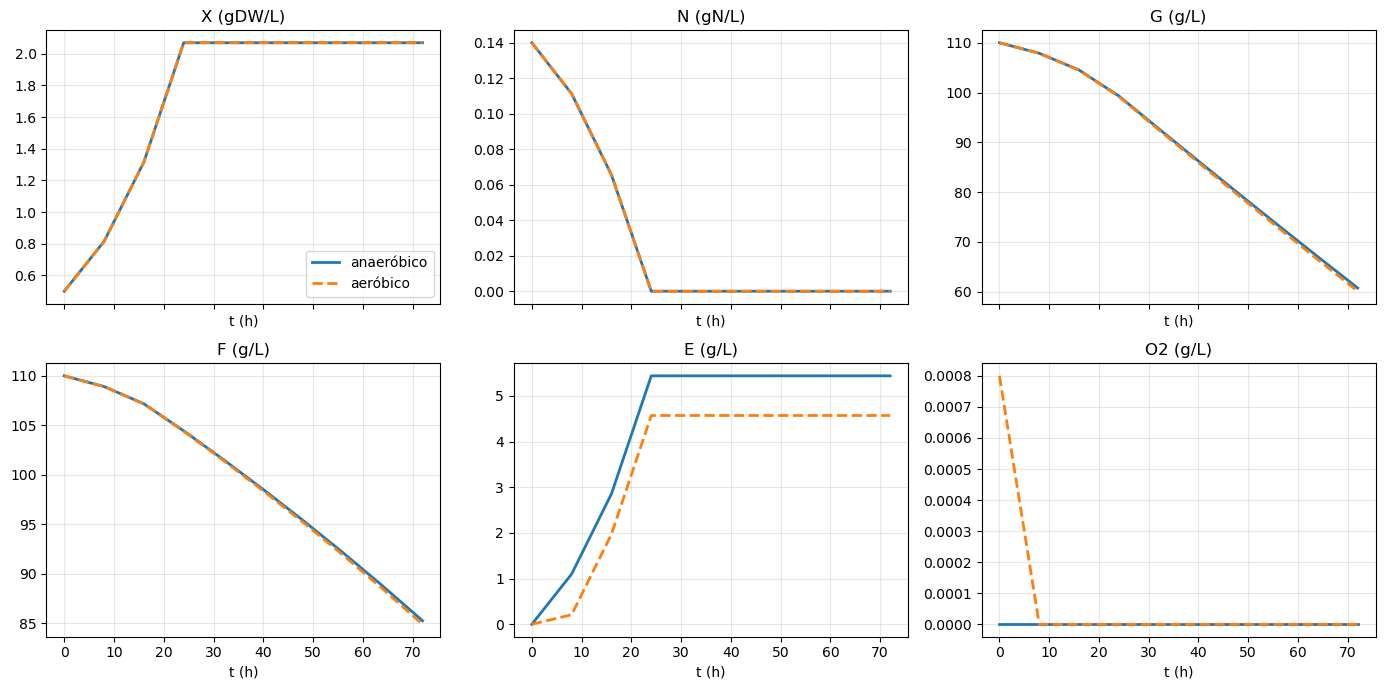

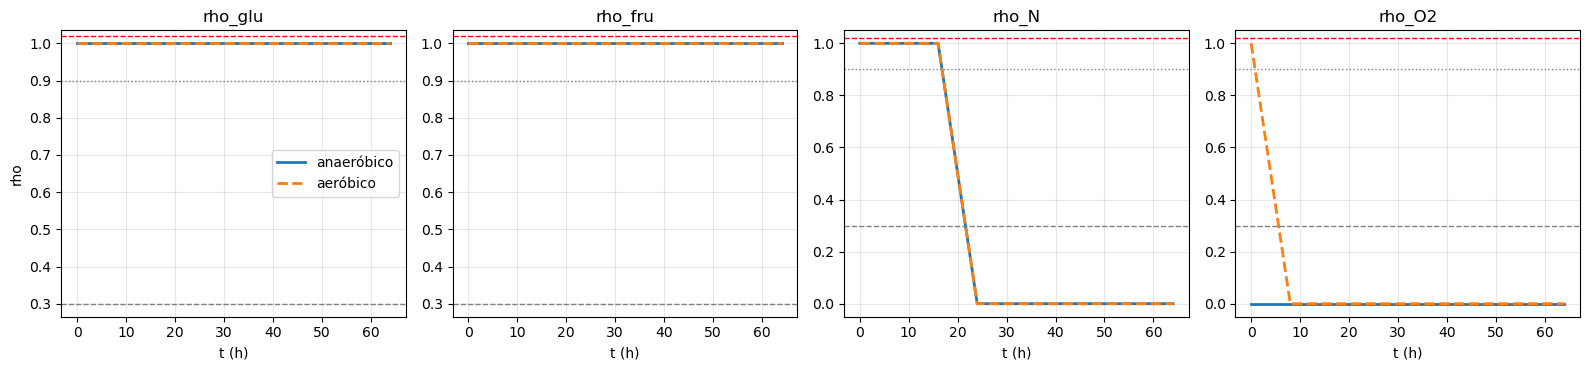

In [17]:
# dFBA SOA básico (dos bloques: anaeróbico y aeróbico)
print("\n" + "=" * 100)
print("dFBA SOA básico con COBRApy (anaeróbico vs aeróbico)")
print("=" * 100)

import matplotlib.pyplot as plt
import re

# Horizonte y paso
DFBA_TH = 72.0
DFBA_DT = 8.0
n_steps = int(round(DFBA_TH / DFBA_DT))
time_grid = np.arange(n_steps + 1, dtype=float) * DFBA_DT

# Escenario aeróbico
O2_INIT_MG_L_AEROBIC = 0.8
O2_INIT_G_L_AEROBIC = O2_INIT_MG_L_AEROBIC / 1000.0
O2_KO_G_L = 0.002
O2_VMAX_UPTAKE = 2.0
O2_DEPLETION_THRESHOLD = 1e-6

# Cierre de uptake nitrogenado al agotarse N
N_DEPLETION_CLOSE_THRESHOLD = 1e-6
VITAMIN_TRACE_IDS = ["r_2067", "r_1671", "r_1967", "r_2028", "r_1548", "r_2038", "r_1947"]

def _n_atoms_from_formula(formula):
    if not formula:
        return 0
    mm = re.search(r"N(?![a-z])(\d*)", str(formula))
    if not mm:
        return 0
    gg = mm.group(1)
    return 1 if gg == "" else int(gg)

N_VITAMIN_EX_IDS = []
for rid in VITAMIN_TRACE_IDS:
    if rid in rxn_by_id and rxn_by_id[rid].metabolites:
        met = next(iter(rxn_by_id[rid].metabolites.keys()))
        if _n_atoms_from_formula(getattr(met, "formula", "")) > 0:
            N_VITAMIN_EX_IDS.append(rid)

MW_O2 = 0.031998

# IDs clave
OBJ_ID = "r_2111"
GLU_ID = "r_1714"
FRU_ID = "r_1709"
ETH_ID = "r_1761"
O2_ID = "r_1992"

required_ids = [OBJ_ID, GLU_ID, FRU_ID, ETH_ID, O2_ID] + KINETIC_N_SOURCE_IDS
missing = [rid for rid in required_ids if rid not in rxn_by_id]
if missing:
    raise RuntimeError(f"Faltan reacciones requeridas para dFBA: {missing}")

base_lb = {rid: float(rxn_by_id[rid].lower_bound) for rid in required_ids}
base_ub = {rid: float(rxn_by_id[rid].upper_bound) for rid in required_ids}

print(f"Regla N-depletion: cierre de vitaminas N cuando N <= {N_DEPLETION_CLOSE_THRESHOLD:g}")
print(f"Exchanges vitaminas-N afectados: {N_VITAMIN_EX_IDS}")

def _kinetic_limits(cX, cN, cG, cF, cE, cO2):
    mu_T  = np.exp(59453.0 * (T_val - 300.0) / (300.0 * R_GAS * T_val))
    Kg_T  = np.exp(46055.0 * (T_val - 293.15) / (293.15 * R_GAS * T_val))
    b_T   = np.exp(11000.0 * (T_val - 296.15) / (296.15 * R_GAS * T_val))
    mrate = MRATE_0 * np.exp(37681.0 * (T_val - 293.30) / (293.30 * R_GAS * T_val))

    mu = MU0_nom * mu_T * (cN / (cN + Kn0_nom * Kg_T + EPS))
    betaG = betaG0_nom * b_T * (cG / (cG + Kg0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))
    betaF = betaF0_nom * b_T * (cF / (cF + Kf0_nom * Kg_T + EPS)) * (Kig0_nom * Kg_T / (cG + Kig0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))

    vx = mu
    vg = mu / YXG_nom + betaG / YEG_nom + mrate * (cG / (cG + cF + EPS))
    vf = mu / YXF_nom + betaF / YEF_nom + mrate * (cF / (cG + cF + EPS))
    vn = mu / YXN_nom
    ve = (betaG + betaF) / MW_ETH

    lim_glu = max(0.0, vg / MW_GLU)
    lim_fru = max(0.0, vf / MW_FRU)
    lim_eth = max(0.0, ve)
    lim_obj = max(0.0, vx)
    lim_n_map = {rid: max(0.0, vn * N_frac_map[rid]) for rid in KINETIC_N_SOURCE_IDS}

    return lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map

def _run_dfba_scenario(*, scenario_name, o2_init_g_l, aerobic_mode):
    y0 = np.array([0.5, 0.14, 110.0, 110.0, 0.0, o2_init_g_l], dtype=float)

    def _apply_dynamic_bounds(mtmp, y):
        cX, cN, cG, cF, cE, cO2 = [max(0.0, float(v)) for v in y]
        lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits(cX, cN, cG, cF, cE, cO2)

        rb = {r.id: r for r in mtmp.reactions}
        for rid in required_ids:
            rb[rid].lower_bound = base_lb[rid]
            rb[rid].upper_bound = base_ub[rid]

        rb[GLU_ID].lower_bound = max(rb[GLU_ID].lower_bound, -lim_glu)
        rb[GLU_ID].upper_bound = min(rb[GLU_ID].upper_bound, 0.0)
        rb[FRU_ID].lower_bound = max(rb[FRU_ID].lower_bound, -lim_fru)
        rb[FRU_ID].upper_bound = min(rb[FRU_ID].upper_bound, 0.0)

        for rid in KINETIC_N_SOURCE_IDS:
            Li = float(lim_n_map[rid])
            rb[rid].lower_bound = max(rb[rid].lower_bound, -Li)
            rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

        if cN <= N_DEPLETION_CLOSE_THRESHOLD:
            for rid in N_VITAMIN_EX_IDS:
                if rid in rb:
                    rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        if APPLY_PRODUCT_CAPS:
            rb[ETH_ID].upper_bound = min(rb[ETH_ID].upper_bound, lim_eth)
            rb[OBJ_ID].upper_bound = min(rb[OBJ_ID].upper_bound, lim_obj)
        else:
            rb[ETH_ID].upper_bound = max(rb[ETH_ID].upper_bound, 1000.0)
            rb[OBJ_ID].upper_bound = max(rb[OBJ_ID].upper_bound, 1000.0)

        if aerobic_mode:
            lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS))
            lim_o2 = max(0.0, float(lim_o2))
            if cO2 <= O2_DEPLETION_THRESHOLD:
                lim_o2 = 0.0
            rb[O2_ID].lower_bound = -lim_o2
            rb[O2_ID].upper_bound = 0.0
        else:
            lim_o2 = 0.0
            rb[O2_ID].lower_bound = 0.0
            rb[O2_ID].upper_bound = 0.0

        lim_n_total = sum(lim_n_map[rid] * N_atoms_map[rid] * MW_N for rid in KINETIC_N_SOURCE_IDS)
        return lim_glu, lim_fru, lim_eth, lim_obj, lim_n_total, lim_o2

    Y = np.zeros((n_steps + 1, 6), dtype=float)
    Y[0, :] = y0

    mu_hist = np.zeros(n_steps)
    vglu_hist = np.zeros(n_steps)
    vfru_hist = np.zeros(n_steps)
    veth_hist = np.zeros(n_steps)
    vo2_hist = np.zeros(n_steps)
    vn_eff_hist = np.zeros(n_steps)
    lim_glu_hist = np.zeros(n_steps)
    lim_fru_hist = np.zeros(n_steps)
    lim_n_hist = np.zeros(n_steps)
    lim_o2_hist = np.zeros(n_steps)

    for k in range(n_steps):
        yk = np.maximum(Y[k, :], 0.0)

        with model as mtmp:
            lim_glu, lim_fru, _lim_eth, _lim_obj, lim_n_total, lim_o2 = _apply_dynamic_bounds(mtmp, yk)
            sol = mtmp.optimize()

            if sol.status != "optimal":
                continue

            v_obj = float(sol.fluxes.get(OBJ_ID, 0.0))
            v_glu = float(sol.fluxes.get(GLU_ID, 0.0))
            v_fru = float(sol.fluxes.get(FRU_ID, 0.0))
            v_eth = float(sol.fluxes.get(ETH_ID, 0.0))
            v_o2 = float(sol.fluxes.get(O2_ID, 0.0))

            vn_eff = 0.0
            for rid in KINETIC_N_SOURCE_IDS:
                v_i = float(sol.fluxes.get(rid, 0.0))
                vn_eff += max(0.0, -v_i) * N_atoms_map[rid] * MW_N

        mu_hist[k] = max(0.0, v_obj)
        vglu_hist[k] = max(0.0, -v_glu)
        vfru_hist[k] = max(0.0, -v_fru)
        veth_hist[k] = max(0.0, v_eth)
        vo2_hist[k] = max(0.0, -v_o2)
        vn_eff_hist[k] = max(0.0, vn_eff)
        lim_glu_hist[k] = max(0.0, lim_glu)
        lim_fru_hist[k] = max(0.0, lim_fru)
        lim_n_hist[k] = max(0.0, lim_n_total)
        lim_o2_hist[k] = max(0.0, lim_o2)

        cX = max(0.0, yk[0])
        dX = v_obj * cX
        dN = -vn_eff * cX
        dG = -MW_GLU * max(0.0, -v_glu) * cX
        dF = -MW_FRU * max(0.0, -v_fru) * cX
        dE =  MW_ETH * max(0.0,  v_eth) * cX
        dO2 = -MW_O2  * max(0.0, -v_o2) * cX

        Y[k + 1, 0] = max(0.0, yk[0] + DFBA_DT * dX)
        Y[k + 1, 1] = max(0.0, yk[1] + DFBA_DT * dN)
        Y[k + 1, 2] = max(0.0, yk[2] + DFBA_DT * dG)
        Y[k + 1, 3] = max(0.0, yk[3] + DFBA_DT * dF)
        Y[k + 1, 4] = max(0.0, yk[4] + DFBA_DT * dE)
        Y[k + 1, 5] = max(0.0, yk[5] + DFBA_DT * dO2)

    X_hist = Y[:, 0]
    N_hist = Y[:, 1]
    G_hist = Y[:, 2]
    F_hist = Y[:, 3]
    E_hist = Y[:, 4]
    O2_hist = Y[:, 5]

    EPS_RHO = 1e-12
    rho_glu = vglu_hist / np.maximum(lim_glu_hist, EPS_RHO)
    rho_fru = vfru_hist / np.maximum(lim_fru_hist, EPS_RHO)
    rho_nit = vn_eff_hist / np.maximum(lim_n_hist, EPS_RHO)
    rho_o2 = vo2_hist / np.maximum(lim_o2_hist, EPS_RHO)

    aerobic_steps = np.where(O2_hist[:-1] > O2_DEPLETION_THRESHOLD)[0]
    if aerobic_steps.size > 0:
        t_transition_h = float(time_grid[int(aerobic_steps[-1]) + 1])
    else:
        t_transition_h = 0.0

    print("\n" + "=" * 100)
    print(f"Bloque dFBA: {scenario_name}")
    print("=" * 100)
    print(f"Estado final: X={X_hist[-1]:.4f}, N={N_hist[-1]:.4f}, G={G_hist[-1]:.4f}, F={F_hist[-1]:.4f}, E={E_hist[-1]:.4f}, O2={O2_hist[-1]:.6f}")
    if aerobic_mode:
        print(f"O2 inicial: {o2_init_g_l*1000.0:.4f} mg/L | Transición estimada a anaerobiosis: t≈{t_transition_h:.2f} h")
    else:
        print("O2 inicial: 0.0000 mg/L | Condición anaeróbica fija (r_1992 cerrado)")

    file_suffix = "aerobic" if aerobic_mode else "anaerobic"
    out_file = OUT_DIR / f"dfba_direct_states_{file_suffix}.csv"
    arr_out = np.column_stack([time_grid, X_hist, N_hist, G_hist, F_hist, E_hist, O2_hist])
    np.savetxt(out_file, arr_out, delimiter=",", header="t_h,X_gDW_L,N_gN_L,G_g_L,F_g_L,E_g_L,O2_g_L", comments="")
    print(f"Archivo guardado: {out_file}")

    return {
        "name": scenario_name,
        "X_hist": X_hist,
        "N_hist": N_hist,
        "G_hist": G_hist,
        "F_hist": F_hist,
        "E_hist": E_hist,
        "O2_hist": O2_hist,
        "rho_glu": rho_glu,
        "rho_fru": rho_fru,
        "rho_nit": rho_nit,
        "rho_o2": rho_o2,
    }

# Bloque 1: anaeróbico
res_ana = _run_dfba_scenario(
    scenario_name="Anaeróbico",
    o2_init_g_l=0.0,
    aerobic_mode=False,
)

# Bloque 2: aeróbico (arranque con 0.8 mg/L O2)
res_aer = _run_dfba_scenario(
    scenario_name="Aeróbico (arranque O2=0.8 mg/L)",
    o2_init_g_l=O2_INIT_G_L_AEROBIC,
    aerobic_mode=True,
)

# Comparación gráfica de estados
fig, ax = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
series = [
    ("X_hist", "X (gDW/L)"),
    ("N_hist", "N (gN/L)"),
    ("G_hist", "G (g/L)"),
    ("F_hist", "F (g/L)"),
    ("E_hist", "E (g/L)"),
    ("O2_hist", "O2 (g/L)"),
]
for a, (key, lbl) in zip(ax.ravel(), series):
    a.plot(time_grid, res_ana[key], lw=2, label="anaeróbico")
    a.plot(time_grid, res_aer[key], lw=2, ls="--", label="aeróbico")
    a.set_title(lbl)
    a.grid(alpha=0.3)
    a.set_xlabel("t (h)")
ax.ravel()[0].legend()
plt.tight_layout()
plt.show()

# Comparación gráfica de activación de restricciones
fig, ax = plt.subplots(1, 4, figsize=(16, 3.8), sharex=True)
rho_map = [
    ("rho_glu", "rho_glu"),
    ("rho_fru", "rho_fru"),
    ("rho_nit", "rho_N"),
    ("rho_o2", "rho_O2"),
]
t_rho = time_grid[:-1]
for a, (key, title) in zip(ax, rho_map):
    a.plot(t_rho, res_ana[key], lw=2, label="anaeróbico")
    a.plot(t_rho, res_aer[key], lw=2, ls="--", label="aeróbico")
    a.axhline(0.30, color="gray", ls="--", lw=1)
    a.axhline(0.90, color="gray", ls=":", lw=1)
    a.axhline(1.02, color="red", ls="--", lw=1)
    a.set_title(title)
    a.set_xlabel("t (h)")
    a.grid(alpha=0.3)
ax[0].set_ylabel("rho")
ax[0].legend()
plt.tight_layout()
plt.show()

In [18]:
# pFBA/pFVA en el punto de agotamiento de N (usando restricciones dinámicas del estado dFBA)
print("\n" + "=" * 100)
print("Análisis pFBA/pFVA en agotamiento de nitrógeno")
print("=" * 100)

import re

required_vars = [
    "model", "rxn_by_id", "KINETIC_N_SOURCE_IDS", "N_atoms_map", "N_frac_map",
    "res_ana", "res_aer", "time_grid",
    "base_lb", "base_ub", "_kinetic_limits",
    "OBJ_ID", "GLU_ID", "FRU_ID", "ETH_ID", "O2_ID",
    "O2_VMAX_UPTAKE", "O2_KO_G_L", "O2_DEPLETION_THRESHOLD", "APPLY_PRODUCT_CAPS",
]
missing_req = [x for x in required_vars if x not in globals()]
if missing_req:
    raise RuntimeError(f"Faltan variables requeridas en sesión: {missing_req}")

N_DEPLETION_THRESHOLD = 1e-6
PFVA_FRACTION = 0.99


def _n_atoms_from_formula(formula):
    if not formula:
        return 0
    mm = re.search(r"N(?![a-z])(\d*)", str(formula))
    if not mm:
        return 0
    gg = mm.group(1)
    return 1 if gg == "" else int(gg)


def _analyze_at_n_depletion(res_dict, scenario_name, aerobic_mode):
    N_hist = np.asarray(res_dict["N_hist"], dtype=float)
    dep_candidates = np.where(N_hist <= N_DEPLETION_THRESHOLD)[0]
    if dep_candidates.size == 0:
        print("\n" + "-" * 100)
        print(f"{scenario_name}: no se detectó agotamiento de N (N>{N_DEPLETION_THRESHOLD}).")
        return None

    dep_idx = int(dep_candidates[0])
    t_dep = float(time_grid[dep_idx])

    cX = float(res_dict["X_hist"][dep_idx])
    cN = float(res_dict["N_hist"][dep_idx])
    cG = float(res_dict["G_hist"][dep_idx])
    cF = float(res_dict["F_hist"][dep_idx])
    cE = float(res_dict["E_hist"][dep_idx])
    cO2 = float(res_dict["O2_hist"][dep_idx])

    lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits(cX, cN, cG, cF, cE, cO2)

    if aerobic_mode:
        lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS))
        lim_o2 = max(0.0, float(lim_o2))
        if cO2 <= O2_DEPLETION_THRESHOLD:
            lim_o2 = 0.0
    else:
        lim_o2 = 0.0

    mdep = model.copy()
    rxn_dep = {r.id: r for r in mdep.reactions}

    for rid in base_lb:
        if rid in rxn_dep:
            rxn_dep[rid].lower_bound = float(base_lb[rid])
            rxn_dep[rid].upper_bound = float(base_ub[rid])

    if GLU_ID in rxn_dep:
        rxn_dep[GLU_ID].lower_bound = max(rxn_dep[GLU_ID].lower_bound, -lim_glu)
        rxn_dep[GLU_ID].upper_bound = min(rxn_dep[GLU_ID].upper_bound, 0.0)

    if FRU_ID in rxn_dep:
        rxn_dep[FRU_ID].lower_bound = max(rxn_dep[FRU_ID].lower_bound, -lim_fru)
        rxn_dep[FRU_ID].upper_bound = min(rxn_dep[FRU_ID].upper_bound, 0.0)

    for rid in KINETIC_N_SOURCE_IDS:
        if rid in rxn_dep:
            lim_i = float(lim_n_map[rid])
            rxn_dep[rid].lower_bound = max(rxn_dep[rid].lower_bound, -lim_i)
            rxn_dep[rid].upper_bound = min(rxn_dep[rid].upper_bound, 0.0)

    n_close_thr = float(globals().get("N_DEPLETION_CLOSE_THRESHOLD", N_DEPLETION_THRESHOLD))
    n_vitamin_ids = list(globals().get("N_VITAMIN_EX_IDS", []))
    if cN <= n_close_thr:
        for rid in n_vitamin_ids:
            if rid in rxn_dep:
                rxn_dep[rid].lower_bound = max(float(rxn_dep[rid].lower_bound), 0.0)
                rxn_dep[rid].upper_bound = min(float(rxn_dep[rid].upper_bound), 0.0)

    if APPLY_PRODUCT_CAPS:
        if ETH_ID in rxn_dep:
            rxn_dep[ETH_ID].upper_bound = min(rxn_dep[ETH_ID].upper_bound, lim_eth)
        if OBJ_ID in rxn_dep:
            rxn_dep[OBJ_ID].upper_bound = min(rxn_dep[OBJ_ID].upper_bound, lim_obj)
    else:
        if ETH_ID in rxn_dep:
            rxn_dep[ETH_ID].upper_bound = max(rxn_dep[ETH_ID].upper_bound, 1000.0)
        if OBJ_ID in rxn_dep:
            rxn_dep[OBJ_ID].upper_bound = max(rxn_dep[OBJ_ID].upper_bound, 1000.0)

    if O2_ID in rxn_dep:
        rxn_dep[O2_ID].lower_bound = -lim_o2 if aerobic_mode else 0.0
        rxn_dep[O2_ID].upper_bound = 0.0

    mdep.objective = OBJ_ID
    mdep.objective_direction = "max"
    sol_pfba = cobra.flux_analysis.pfba(mdep, fraction_of_optimum=1.0)

    fva_ids = [OBJ_ID, GLU_ID, FRU_ID, ETH_ID, O2_ID] + KINETIC_N_SOURCE_IDS
    fva_ids = [rid for rid in fva_ids if rid in rxn_dep]

    try:
        pfva_df = cobra.flux_analysis.flux_variability_analysis(
            mdep,
            reaction_list=fva_ids,
            fraction_of_optimum=PFVA_FRACTION,
            pfba_factor=1.0,
        )
    except TypeError:
        pfva_df = cobra.flux_analysis.flux_variability_analysis(
            mdep,
            reaction_list=fva_ids,
            fraction_of_optimum=PFVA_FRACTION,
        )

    n_upt_kin = 0.0
    for rid in KINETIC_N_SOURCE_IDS:
        if rid in rxn_dep:
            v_i = float(sol_pfba.fluxes.get(rid, 0.0))
            n_upt_kin += max(0.0, -v_i) * float(N_atoms_map.get(rid, 0.0)) * MW_N

    n_upt_all = []
    for ex in mdep.exchanges:
        rid = ex.id
        v = float(sol_pfba.fluxes.get(rid, 0.0))
        if v >= -1e-9:
            continue
        met = next(iter(ex.metabolites.keys()))
        n_atoms = _n_atoms_from_formula(getattr(met, "formula", ""))
        if n_atoms <= 0:
            continue
        n_upt_all.append((rid, ex.name, met.id, getattr(met, "formula", ""), v, n_atoms, (-v) * n_atoms * MW_N))

    n_upt_all.sort(key=lambda x: x[6], reverse=True)

    mdep_no_n = mdep.copy()
    rxn_no_n = {r.id: r for r in mdep_no_n.reactions}
    for rid in KINETIC_N_SOURCE_IDS:
        if rid in rxn_no_n:
            rxn_no_n[rid].lower_bound = 0.0
            rxn_no_n[rid].upper_bound = min(float(rxn_no_n[rid].upper_bound), 0.0)

    mdep_no_n.objective = OBJ_ID
    mdep_no_n.objective_direction = "max"
    sol_no_n = mdep_no_n.optimize()

    print("\n" + "-" * 100)
    print(f"Escenario: {scenario_name}")
    print("-" * 100)
    print(f"t_agotamiento_N = {t_dep:.3f} h (índice={dep_idx})")
    print(f"Estado usado: X={cX:.6g}, N={cN:.6g}, G={cG:.6g}, F={cF:.6g}, E={cE:.6g}, O2={cO2:.6g}")
    print(f"Límites dinámicos: lim_glu={lim_glu:.6g}, lim_fru={lim_fru:.6g}, lim_o2={lim_o2:.6g}, limN_total={sum(lim_n_map[r]*N_atoms_map[r]*MW_N for r in KINETIC_N_SOURCE_IDS):.6g}")
    print(f"pFBA status={sol_pfba.status} | crecimiento={float(sol_pfba.fluxes.get(OBJ_ID, np.nan)):.6g}")
    print(f"N uptake (fuentes cinéticas, gN/L/h equiv.) = {n_upt_kin:.6g}")

    print("\nFlujos pFBA clave:")
    for rid in fva_ids:
        vv = float(sol_pfba.fluxes.get(rid, np.nan))
        print(f"- {rid}: v={vv:.6g}")

    print("\npFVA @99% (min,max):")
    for rid in fva_ids:
        mn = float(pfva_df.loc[rid, "minimum"])
        mx = float(pfva_df.loc[rid, "maximum"])
        print(f"- {rid}: [{mn:.6g}, {mx:.6g}]")

    print("\nExchanges con N activo (v<0):")
    if not n_upt_all:
        print("- No se detecta uptake de metabolitos con N en exchanges.")
    else:
        for rid, name, mid, formula, v, n_atoms, nrate in n_upt_all[:20]:
            print(f"- {name:38s} ({rid}) | met={mid:12s} formula={str(formula):10s} | v={v:.6g} | N={n_atoms} | N*|v|*MW_N={nrate:.6g}")

    print("\nTest de causalidad (bloqueando KINETIC_N_SOURCE_IDS):")
    print(f"- status={sol_no_n.status} | crecimiento={float(sol_no_n.objective_value if sol_no_n.status=='optimal' else np.nan):.6g}")

    return {
        "scenario": scenario_name,
        "t_dep": t_dep,
        "dep_idx": dep_idx,
        "state": np.array([cX, cN, cG, cF, cE, cO2], dtype=float),
        "sol_pfba": sol_pfba,
        "pfva_df": pfva_df,
        "sol_no_n": sol_no_n,
        "n_upt_kin": n_upt_kin,
        "n_upt_all": n_upt_all,
    }


analysis_dep_ana = _analyze_at_n_depletion(res_ana, "Anaeróbico", aerobic_mode=False)
analysis_dep_aer = _analyze_at_n_depletion(res_aer, "Aeróbico", aerobic_mode=True)

print("\nVariables guardadas:")
print("- analysis_dep_ana")
print("- analysis_dep_aer")


Análisis pFBA/pFVA en agotamiento de nitrógeno

----------------------------------------------------------------------------------------------------
Escenario: Anaeróbico
----------------------------------------------------------------------------------------------------
t_agotamiento_N = 24.000 h (índice=3)
Estado usado: X=2.06949, N=0, G=99.3037, F=104.449, E=5.4384, O2=0
Límites dinámicos: lim_glu=2.19997, lim_fru=0.976158, lim_o2=0, limN_total=0
pFBA status=optimal | crecimiento=0
N uptake (fuentes cinéticas, gN/L/h equiv.) = 0

Flujos pFBA clave:
- r_2111: v=0
- r_1714: v=0
- r_1709: v=-0.35
- r_1761: v=0.7
- r_1992: v=0
- r_1654: v=0
- r_1879: v=0
- r_1891: v=0
- r_1889: v=0
- r_1906: v=0
- r_1911: v=0
- r_1873: v=0
- r_1912: v=0

pFVA @99% (min,max):
- r_2111: [0, 0]
- r_1714: [0, 0]
- r_1709: [-0.35, -0.35]
- r_1761: [0.7, 0.7]
- r_1992: [0, 0]
- r_1654: [0, 0]
- r_1879: [0, 0]
- r_1891: [0, 0]
- r_1889: [0, 0]
- r_1906: [0, 0]
- r_1911: [0, 0]
- r_1873: [0, 0]
- r_1912: [0, 0

In [22]:
# Diagnóstico de destino de carbono post-agotamiento de N (balance por estados + perfil de productos)
print("\n" + "=" * 100)
print("Destino de carbono cuando N se agota")
print("=" * 100)

required_vars = [
    "model", "res_ana", "res_aer", "time_grid", "DFBA_DT",
    "OBJ_ID", "GLU_ID", "FRU_ID", "ETH_ID", "O2_ID", "ATPM_ID",
    "KINETIC_N_SOURCE_IDS", "base_lb", "base_ub", "_kinetic_limits",
    "MW_GLU", "MW_FRU", "MW_ETH",
    "O2_VMAX_UPTAKE", "O2_KO_G_L", "O2_DEPLETION_THRESHOLD",
    "APPLY_PRODUCT_CAPS",
]
missing_req = [x for x in required_vars if x not in globals()]
if missing_req:
    raise RuntimeError(f"Faltan variables requeridas para diagnóstico de carbono: {missing_req}")

PRODUCT_TRACE_IDS = [
    "r_1761", "r_1808", "r_1634", "r_2056", "r_1549", "r_1546",
    "r_1552", "r_1765", "r_1867", "r_1866", "r_1862", "r_1865",
]


def _carbon_atoms(formula):
    if not formula:
        return 0
    mm = re.search(r"C(?![a-z])(\\d*)", str(formula))
    if not mm:
        return 0
    gg = mm.group(1)
    return 1 if gg == "" else int(gg)


def _build_snapshot_model(y_state, aerobic_mode):
    cX, cN, cG, cF, cE, cO2 = [max(0.0, float(v)) for v in y_state]
    lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits(cX, cN, cG, cF, cE, cO2)

    if aerobic_mode:
        lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS))
        lim_o2 = max(0.0, float(lim_o2))
        if cO2 <= O2_DEPLETION_THRESHOLD:
            lim_o2 = 0.0
    else:
        lim_o2 = 0.0

    mtmp = model.copy()
    rxn_tmp = {r.id: r for r in mtmp.reactions}

    for rid in base_lb:
        if rid in rxn_tmp:
            rxn_tmp[rid].lower_bound = float(base_lb[rid])
            rxn_tmp[rid].upper_bound = float(base_ub[rid])

    if GLU_ID in rxn_tmp:
        rxn_tmp[GLU_ID].lower_bound = max(rxn_tmp[GLU_ID].lower_bound, -lim_glu)
        rxn_tmp[GLU_ID].upper_bound = min(rxn_tmp[GLU_ID].upper_bound, 0.0)

    if FRU_ID in rxn_tmp:
        rxn_tmp[FRU_ID].lower_bound = max(rxn_tmp[FRU_ID].lower_bound, -lim_fru)
        rxn_tmp[FRU_ID].upper_bound = min(rxn_tmp[FRU_ID].upper_bound, 0.0)

    for rid in KINETIC_N_SOURCE_IDS:
        if rid in rxn_tmp:
            lim_i = float(lim_n_map[rid])
            rxn_tmp[rid].lower_bound = max(rxn_tmp[rid].lower_bound, -lim_i)
            rxn_tmp[rid].upper_bound = min(rxn_tmp[rid].upper_bound, 0.0)

    n_close_thr = float(globals().get("N_DEPLETION_CLOSE_THRESHOLD", 1e-6))
    n_vitamin_ids = list(globals().get("N_VITAMIN_EX_IDS", []))
    if cN <= n_close_thr:
        for rid in n_vitamin_ids:
            if rid in rxn_tmp:
                rxn_tmp[rid].lower_bound = max(float(rxn_tmp[rid].lower_bound), 0.0)
                rxn_tmp[rid].upper_bound = min(float(rxn_tmp[rid].upper_bound), 0.0)

    if APPLY_PRODUCT_CAPS:
        if ETH_ID in rxn_tmp:
            rxn_tmp[ETH_ID].upper_bound = min(rxn_tmp[ETH_ID].upper_bound, lim_eth)
        if OBJ_ID in rxn_tmp:
            rxn_tmp[OBJ_ID].upper_bound = min(rxn_tmp[OBJ_ID].upper_bound, lim_obj)
    else:
        if ETH_ID in rxn_tmp:
            rxn_tmp[ETH_ID].upper_bound = max(rxn_tmp[ETH_ID].upper_bound, 1000.0)
        if OBJ_ID in rxn_tmp:
            rxn_tmp[OBJ_ID].upper_bound = max(rxn_tmp[OBJ_ID].upper_bound, 1000.0)

    if O2_ID in rxn_tmp:
        rxn_tmp[O2_ID].lower_bound = -lim_o2 if aerobic_mode else 0.0
        rxn_tmp[O2_ID].upper_bound = 0.0

    mtmp.objective = OBJ_ID
    mtmp.objective_direction = "max"
    return mtmp


def _state_carbon_report(res_dict, scenario_name, aerobic_mode):
    N_hist = np.asarray(res_dict["N_hist"], dtype=float)
    G_hist = np.asarray(res_dict["G_hist"], dtype=float)
    F_hist = np.asarray(res_dict["F_hist"], dtype=float)
    E_hist = np.asarray(res_dict["E_hist"], dtype=float)
    X_hist = np.asarray(res_dict["X_hist"], dtype=float)

    dep_candidates = np.where(N_hist <= 1e-6)[0]
    if dep_candidates.size == 0:
        print("\n" + "-" * 100)
        print(f"{scenario_name}: N no se agota en el horizonte simulado.")
        return None

    dep_idx = int(dep_candidates[0])
    t_dep = float(time_grid[dep_idx])
    post_last = len(time_grid) - 1

    C_in_intervals = []
    C_eth_intervals = []
    dX_intervals = []
    vglu_app = []
    vfru_app = []
    veth_app = []

    for k in range(dep_idx, post_last):
        dG = float(G_hist[k + 1] - G_hist[k])
        dF = float(F_hist[k + 1] - F_hist[k])
        dE = float(E_hist[k + 1] - E_hist[k])
        dX = float(X_hist[k + 1] - X_hist[k])
        Xk = max(float(X_hist[k]), 1e-12)

        C_in = max(0.0, -dG) * (6.0 / MW_GLU) + max(0.0, -dF) * (6.0 / MW_FRU)
        C_eth = max(0.0, dE) * (2.0 / MW_ETH)

        vG = max(0.0, -dG) / max(DFBA_DT * MW_GLU * Xk, 1e-12)
        vF = max(0.0, -dF) / max(DFBA_DT * MW_FRU * Xk, 1e-12)
        vE = max(0.0, dE) / max(DFBA_DT * MW_ETH * Xk, 1e-12)

        C_in_intervals.append(C_in)
        C_eth_intervals.append(C_eth)
        dX_intervals.append(dX)
        vglu_app.append(vG)
        vfru_app.append(vF)
        veth_app.append(vE)

    C_in_intervals = np.asarray(C_in_intervals, dtype=float)
    C_eth_intervals = np.asarray(C_eth_intervals, dtype=float)
    dX_intervals = np.asarray(dX_intervals, dtype=float)
    vglu_app = np.asarray(vglu_app, dtype=float)
    vfru_app = np.asarray(vfru_app, dtype=float)
    veth_app = np.asarray(veth_app, dtype=float)

    product_flux_rows = []
    carbon_exchange_sec = {}
    mu_rows = []
    veth_rows = []
    atpm_rows = []

    for k in range(dep_idx, post_last):
        yk = np.array([X_hist[k], N_hist[k], G_hist[k], F_hist[k], E_hist[k], res_dict["O2_hist"][k]], dtype=float)
        with _build_snapshot_model(yk, aerobic_mode) as mtmp:
            sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
            if sol.status != "optimal":
                continue

            mu_rows.append(float(sol.fluxes.get(OBJ_ID, 0.0)))
            veth_rows.append(float(sol.fluxes.get(ETH_ID, 0.0)))
            atpm_rows.append(float(sol.fluxes.get(ATPM_ID, 0.0)))

            for rid in PRODUCT_TRACE_IDS:
                if rid in {r.id for r in mtmp.reactions}:
                    product_flux_rows.append((rid, float(sol.fluxes.get(rid, 0.0))))

            for ex in mtmp.exchanges:
                rid = ex.id
                v = float(sol.fluxes.get(rid, 0.0))
                if v <= 1e-10:
                    continue
                met = next(iter(ex.metabolites.keys()))
                c_atoms = _carbon_atoms(getattr(met, "formula", ""))
                if c_atoms <= 0:
                    continue
                c_rate = v * c_atoms
                key = (rid, ex.name, met.id, getattr(met, "formula", ""))
                carbon_exchange_sec.setdefault(key, []).append(c_rate)

    prod_avg = {}
    for rid, v in product_flux_rows:
        prod_avg.setdefault(rid, []).append(v)
    prod_avg = {rid: float(np.mean(vs)) for rid, vs in prod_avg.items()}

    sec_avg = []
    for key, vals in carbon_exchange_sec.items():
        sec_avg.append((*key, float(np.mean(vals))))
    sec_avg.sort(key=lambda x: x[4], reverse=True)

    print("\n" + "-" * 100)
    print(f"Escenario: {scenario_name}")
    print("-" * 100)
    print(f"Agotamiento de N en t={t_dep:.3f} h (índice {dep_idx})")
    print(f"ΔX medio post-N = {dX_intervals.mean():.6g} gDW/L por paso")
    print(f"C de azúcares consumido post-N (medio) = {C_in_intervals.mean():.6g} C-mol/L por paso")
    print(f"C hacia etanol post-N (medio) = {C_eth_intervals.mean():.6g} C-mol/L por paso")
    print(f"Fracción C->etanol post-N = {(C_eth_intervals.mean()/max(C_in_intervals.mean(),1e-12)):.6g}")
    print(f"Tasas aparentes desde estados: vG={vglu_app.mean():.6g}, vF={vfru_app.mean():.6g}, vE={veth_app.mean():.6g}")

    if mu_rows:
        print(f"pFBA snapshot post-N: mu medio={float(np.mean(mu_rows)):.6g}, v_eth medio={float(np.mean(veth_rows)):.6g}, ATPM medio={float(np.mean(atpm_rows)):.6g}")

    if prod_avg:
        print("\nFlujo medio de productos post-N (top por |v|):")
        rxn_map = {r.id: r for r in model.reactions}
        for rid, vv in sorted(prod_avg.items(), key=lambda kv: abs(kv[1]), reverse=True)[:12]:
            rname = rxn_map[rid].name if rid in rxn_map else "?"
            print(f"- {rname:34s} ({rid}) | v_prom={vv:.6g}")

    if sec_avg:
        print("\nTop excreciones carbonadas por exchanges (C-atoms*v):")
        for rid, name, mid, formula, c_rate in sec_avg[:12]:
            print(f"- {name:34s} ({rid}) | met={mid:12s} formula={str(formula):10s} | C*v={c_rate:.6g}")
    else:
        print("\nNo se detectaron excreciones carbonadas en exchanges para snapshots post-N.")

    interpretation = ""
    if C_in_intervals.mean() > 1e-8 and C_eth_intervals.mean() <= 1e-8:
        interpretation = "postN_no_ethanol"
    elif C_in_intervals.mean() <= 1e-8:
        interpretation = "postN_no_sugar_uptake"
    else:
        interpretation = "postN_with_ethanol"

    return {
        "scenario": scenario_name,
        "t_dep": t_dep,
        "dep_idx": dep_idx,
        "C_in_mean": float(C_in_intervals.mean()),
        "C_eth_mean": float(C_eth_intervals.mean()),
        "dX_mean": float(dX_intervals.mean()),
        "vglu_app_mean": float(vglu_app.mean()),
        "vfru_app_mean": float(vfru_app.mean()),
        "veth_app_mean": float(veth_app.mean()),
        "mu_mean": float(np.mean(mu_rows)) if mu_rows else np.nan,
        "veth_mean": float(np.mean(veth_rows)) if veth_rows else np.nan,
        "atpm_mean": float(np.mean(atpm_rows)) if atpm_rows else np.nan,
        "product_flux_avg": prod_avg,
        "exchange_carbon_secretion_avg": sec_avg,
        "interpretation": interpretation,
    }


carbon_postN_ana = _state_carbon_report(res_ana, "Anaeróbico", aerobic_mode=False)
carbon_postN_aer = _state_carbon_report(res_aer, "Aeróbico", aerobic_mode=True)

print("\nVariables guardadas:")
print("- carbon_postN_ana")
print("- carbon_postN_aer")


Destino de carbono cuando N se agota

----------------------------------------------------------------------------------------------------
Escenario: Anaeróbico
----------------------------------------------------------------------------------------------------
Agotamiento de N en t=24.000 h (índice 3)
ΔX medio post-N = -7.40149e-17 gDW/L por paso
C de azúcares consumido post-N (medio) = 320.517 C-mol/L por paso
C hacia etanol post-N (medio) = 0 C-mol/L por paso
Fracción C->etanol post-N = 0
Tasas aparentes desde estados: vG=2.1552, vF=1.0714, vE=0
pFBA snapshot post-N: mu medio=0, v_eth medio=0.7, ATPM medio=0.7

Flujo medio de productos post-N (top por |v|):
- ethanol exchange                   (r_1761) | v_prom=0.7
- glycerol exchange                  (r_1808) | v_prom=-3.47309e-16
- (R,R)-2,3-butanediol exchange      (r_1549) | v_prom=-1.55431e-16
- acetate exchange                   (r_1634) | v_prom=0
- succinate exchange                 (r_2056) | v_prom=0
- (R)-lactate exchang

In [23]:
# Listado completo de exchanges post-agotamiento de N
print("\n" + "=" * 100)
print("Listado completo de exchanges post-N")
print("=" * 100)

required_vars = [
    "model", "res_ana", "res_aer", "time_grid", "_build_snapshot_model"
]
missing_req = [x for x in required_vars if x not in globals()]
if missing_req:
    raise RuntimeError(f"Faltan variables para listar exchanges post-N: {missing_req}")


def _print_all_exchanges_postN(res_dict, scenario_name, aerobic_mode):
    N_hist = np.asarray(res_dict["N_hist"], dtype=float)
    dep_candidates = np.where(N_hist <= 1e-6)[0]
    if dep_candidates.size == 0:
        print("\n" + "-" * 100)
        print(f"{scenario_name}: no se detectó agotamiento de N")
        return None

    dep_idx = int(dep_candidates[0])
    t_dep = float(time_grid[dep_idx])

    yk = np.array([
        res_dict["X_hist"][dep_idx],
        res_dict["N_hist"][dep_idx],
        res_dict["G_hist"][dep_idx],
        res_dict["F_hist"][dep_idx],
        res_dict["E_hist"][dep_idx],
        res_dict["O2_hist"][dep_idx],
    ], dtype=float)

    with _build_snapshot_model(yk, aerobic_mode) as mtmp:
        sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
        if sol.status != "optimal":
            print("\n" + "-" * 100)
            print(f"{scenario_name}: sin solución óptima en t={t_dep:.3f} h")
            return None

        rows = []
        for ex in mtmp.exchanges:
            rid = ex.id
            v = float(sol.fluxes.get(rid, 0.0))
            lb = float(ex.lower_bound)
            ub = float(ex.upper_bound)
            met = next(iter(ex.metabolites.keys())) if ex.metabolites else None
            mid = met.id if met is not None else ""
            formula = getattr(met, "formula", "") if met is not None else ""
            if v < -1e-10:
                direction = "uptake"
            elif v > 1e-10:
                direction = "secretion"
            else:
                direction = "zero"
            rows.append((rid, ex.name, mid, formula, v, lb, ub, direction))

        rows.sort(key=lambda x: abs(x[4]), reverse=True)

        print("\n" + "-" * 100)
        print(f"Escenario: {scenario_name}")
        print("-" * 100)
        print(f"Snapshot en agotamiento de N: t={t_dep:.3f} h (índice {dep_idx})")
        print(f"Total exchanges listados: {len(rows)}")
        print("\nFormato: [direction] name (id) | v | [lb, ub] | met | formula")

        for rid, name, mid, formula, v, lb, ub, direction in rows:
            print(
                f"- [{direction:9s}] {name:34s} ({rid}) | "
                f"v={v: .6g} | [{lb: .6g}, {ub: .6g}] | "
                f"met={mid:12s} | formula={str(formula):10s}"
            )

        return rows


all_exchanges_postN_ana = _print_all_exchanges_postN(res_ana, "Anaeróbico", aerobic_mode=False)
all_exchanges_postN_aer = _print_all_exchanges_postN(res_aer, "Aeróbico", aerobic_mode=True)

print("\nVariables guardadas:")
print("- all_exchanges_postN_ana")
print("- all_exchanges_postN_aer")


Listado completo de exchanges post-N

----------------------------------------------------------------------------------------------------
Escenario: Anaeróbico
----------------------------------------------------------------------------------------------------
Snapshot en agotamiento de N: t=24.000 h (índice 3)
Total exchanges listados: 271

Formato: [direction] name (id) | v | [lb, ub] | met | formula
- [secretion] ethanol exchange                   (r_1761) | v= 0.7 | [ 0,  1000] | met=s_0681       | formula=C2H6O     
- [secretion] carbon dioxide exchange            (r_1672) | v= 0.7 | [ 0,  1000] | met=s_0458       | formula=CO2       
- [uptake   ] D-fructose exchange                (r_1709) | v=-0.35 | [-0.976158,  0] | met=s_0554       | formula=C6H12O6   
- [zero     ] ethyl-pyruvate exchange            (r_4737) | v= 5.62345e-16 | [ 0,  1000] | met=s_4281       | formula=C5H8O3    
- [zero     ] water exchange                     (r_2100) | v= 5.19366e-16 | [-1000,  1000] | m

In [24]:
# Guardar listado completo de exchanges post-N a CSV (más cómodo para revisar)
import csv

OUT_DIR.mkdir(exist_ok=True)


def _save_exchange_rows(rows, out_path):
    if rows is None:
        return
    with open(out_path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["exchange_id", "exchange_name", "met_id", "formula", "flux", "lb", "ub", "direction"])
        for rid, name, mid, formula, v, lb, ub, direction in rows:
            w.writerow([rid, name, mid, formula, v, lb, ub, direction])

file_ana = OUT_DIR / "all_exchanges_postN_anaerobic.csv"
file_aer = OUT_DIR / "all_exchanges_postN_aerobic.csv"

_save_exchange_rows(all_exchanges_postN_ana, file_ana)
_save_exchange_rows(all_exchanges_postN_aer, file_aer)

print(f"CSV guardado: {file_ana}")
print(f"CSV guardado: {file_aer}")

CSV guardado: out\all_exchanges_postN_anaerobic.csv
CSV guardado: out\all_exchanges_postN_aerobic.csv


In [14]:
# Normalizar tipos de bounds para exportacion SBML segura
for r in model.reactions:
    r.lower_bound = float(r.lower_bound)
    r.upper_bound = float(r.upper_bound)

cobra.io.write_sbml_model(model, str(MODEL_READY_SBML))

S = create_stoichiometric_matrix(model, array_type="dense")
lb = np.array([r.lower_bound for r in model.reactions], dtype=float)
ub = np.array([r.upper_bound for r in model.reactions], dtype=float)
rxn_ids = [r.id for r in model.reactions]
met_ids = [m.id for m in model.metabolites]

np.savetxt(S_FILE, S, delimiter=",")
np.savetxt(LB_FILE, lb, delimiter=",")
np.savetxt(UB_FILE, ub, delimiter=",")
newline = chr(10)
RXN_FILE.write_text(newline.join(rxn_ids), encoding="utf-8")
MET_FILE.write_text(newline.join(met_ids), encoding="utf-8")

print("Export completado")
print(f"- model_ready: {MODEL_READY_SBML}")
print(f"- S shape: {S.shape}")
print(f"- lb shape: {lb.shape}")
print(f"- ub shape: {ub.shape}")
print(f"- rxn ids: {len(rxn_ids)}")
print(f"- met ids: {len(met_ids)}")


Export completado
- model_ready: out\model_ready.xml
- S shape: (2806, 4131)
- lb shape: (4131,)
- ub shape: (4131,)
- rxn ids: 4131
- met ids: 2806


In [15]:
S_chk = np.loadtxt(S_FILE, delimiter=",")
lb_chk = np.loadtxt(LB_FILE, delimiter=",")
ub_chk = np.loadtxt(UB_FILE, delimiter=",")

assert S_chk.shape == (len(met_ids), len(rxn_ids))
assert lb_chk.shape[0] == len(rxn_ids)
assert ub_chk.shape[0] == len(rxn_ids)

print("Validacion final OK")
print(f"- S.csv : {S_FILE.resolve()}")
print(f"- lb.csv: {LB_FILE.resolve()}")
print(f"- ub.csv: {UB_FILE.resolve()}")


Validacion final OK
- S.csv : C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out\S.csv
- lb.csv: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out\lb.csv
- ub.csv: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out\ub.csv
